# imports

imports

In [1]:
import sys
sys.path.append('/home/cg5763/icl')

import re
import torch, math
import torch.nn as nn
import torch.nn.functional as F
from itertools import combinations
from typing import List, Tuple, Dict
import pandas as pd
import math, ast
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import base.utils as u
import numpy as np
from pathlib import Path
from matplotlib.patches import Rectangle
from scipy.optimize import curve_fit
from pd.compute import naming
from brokenaxes import brokenaxes

In [2]:
OUTPUT_DIR = Path('/scratch/gpfs/GREDDY/cg5763/output')

plotting params

In [3]:
plt.rcParams.update({
    # "legend.frameon": False,
    # "text.usetex": True,
    # "font.family": "serif",
    # "font.size": 8,
    "figure.figsize": (3, 2),
    # 'axes.titlesize': 8,
    # 'figure.dpi': 150,
    # "pdf.fonttype": 3,   # embed TrueType (Type 42) instead of Type 3
    # "ps.fonttype": 3,
})

import matplotlib as mpl

mpl.rcParams.update({

    # --- Use LaTeX for all text ---
    "text.usetex": True,

    # Ensure Times-like fonts consistent with APS papers
    "font.family": "serif",

    # # LaTeX preamble
    # "text.latex.preamble": r"""
    #     \usepackage{amsmath}
    #     \usepackage{amssymb}
    #     \usepackage{newtxtext}
    #     \usepackage{newtxmath}
    # """,

    # --- Font sizes ---
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,

    # --- Axes ---
    "axes.linewidth": 0.8,
    "axes.labelpad": 2,

    # --- Ticks (APS style) ---
    "xtick.direction": "in",
    "ytick.direction": "in",
    # "xtick.top": True,
    # "ytick.right": True,

    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,

    "xtick.major.pad": 1.5,
    "ytick.major.pad": 1.5,

    # --- Lines ---
    "lines.linewidth": 1.0,
    "lines.markersize": 3,

    # --- Legend ---
    "legend.frameon": False,
    "legend.handlelength": 1.2,
    "legend.borderpad": 0.2,

    # --- Export ---
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

# sns.set_theme(
#     context="paper",
#     style="ticks",
#     rc={
#         "text.usetex": True,
#         "font.family": "serif",
#         "font.size": 8,
#         "axes.linewidth": 0.8,
#         "xtick.direction": "in",
#         "ytick.direction": "in",
#         "legend.frameon": False,
#         "figure.figsize": (3, 2),
#     }
# )

plot_dir=Path("./plots")

## utilities

general

In [4]:
def get_state_idx(config, path, t: int):
    """Get state idx for state at time t' <= t"""
    state_iters = np.array(config.log.state.state_iters)
    state_idx = len(state_iters[state_iters < t])-1

    path = Path(path)
    for idx in range(state_idx+1, 1000):
        test_path = path / f'{idx}.pt'
        if test_path.exists():
            test_state_dict = torch.load(test_path)
            s = test_state_dict['iter']
            if s > t:
                return idx-1
                break
        else:
            print(f"State file {test_path} does not exist. Returning last valid index {idx-1}.")
            return idx-1
            break

def filter_t(df, t_value, t_col='t'):
    """
    Returns a filtered DataFrame with rows where s_col is the closest value ≤ s_value.
    If all values are greater than s_value, returns the smallest s_col instead.
    """
    if t_value is None:
        raise ValueError("You must provide s_value.")

    # Filter to those <= s_value if possible
    subset = df[df[t_col] <= t_value]
    if subset.empty:
        # fallback: take the smallest s
        subset = df

    # find the row(s) with the closest s
    closest_val = subset[t_col].max()
    return closest_val, df[df[t_col] == closest_val]

def mask_df(df: pd.DataFrame, exp_config, seed_idx, n_idx, param_idx, param_name: str = None):
    if param_name is None:
        param_name == exp_config.param_name
    return df[(df['seed'] == exp_config.seedrange[seed_idx]) & (df['n'] == exp_config.nrange[n_idx]) & (df[param_name] == exp_config.paramrange[param_idx])]

def process_edge_causal(edge_causal: pd.DataFrame):
    names = {
        '0': 'tok',
        '1': 'a1',
        '2': 'm1',
        '3': 'a2',
        '4': 'm2'
    }

    full_loss = edge_causal[edge_causal['n_edges'] == 10].copy(deep = True)
    out = edge_causal[edge_causal['n_edges'] == 9].copy(deep = True)
    out['str_disabled_edges'] = out['disabled_edges'].apply(lambda x: names[x[2]] + '_' + names[x[5]])
    return full_loss, out

def name(seed, k, n):
    return f'S{seed}_K{k}_N{n}'

def get_params(exp_config, seed_idx, param_idx, n_idx):
    seed = exp_config.seedrange[seed_idx]
    k = exp_config.paramrange[param_idx]
    n = exp_config.nrange[n_idx]

    return seed, k, n

def load_config(base_dir: str, seed_idx: int, k_idx: int, n_idx: int):
    base_dir = Path(base_dir)
    exp_config = u.load_config(base_dir / 'exp_config.yaml')
    seed, k, n = get_params(exp_config, seed_idx, k_idx, n_idx)
    config = u.load_config_and_task_pool(base_dir / 'data' / name(seed, k, n))
    
    return config

def load_model(base_dir: str, seed_idx: int, k_idx: int, n_idx: int):
    config = load_config(base_dir, seed_idx, k_idx, n_idx)
    get_model = u.dynamic_import(exp_config.model, 'get_model_safe')
    
    return get_model(config)

def load_task_model(base_dir: str, seed_idx: int, k_idx: int, n_idx: int):
    base_dir = Path(base_dir)
    exp_config = u.load_config(base_dir / 'exp_config.yaml')
    config = load_config(base_dir, seed_idx, k_idx, n_idx)
    get_task_model = u.dynamic_import(exp_config.task_model, 'get_task_model_safe')
    
    return get_task_model(config)

def load_all(base_dir: str, seed_idx: int, k_idx: int, n_idx: int):
    base_dir = Path(base_dir)
    return load_config(base_dir, seed_idx, k_idx, n_idx), load_model(base_dir, seed_idx, k_idx, n_idx), load_task_model(base_dir, seed_idx, k_idx, n_idx)

def get_state_dict(base_dir: str, seed_idx: int, k_idx: int, n_idx: int, state: int = None):
    base_dir = Path(base_dir)
    exp_config = u.load_config(base_dir / 'exp_config.yaml')
    seed, k, n = get_params(exp_config, seed_idx, k_idx, n_idx)
    state_dir = base_dir / 'data' / name(seed, k, n) / 'state'
    if state is None:
        pt_files = [
            f for f in state_dir.glob("*.pt")
            if f.stem.isdigit()
        ]
        state = max(int(f.stem) for f in pt_files)
    load = torch.load(state_dir / f'{state}.pt')
    iter, state_dict = load['iter'], load['state']
    return iter, state_dict

In [5]:
def ablation_losses(
    model: nn.Module,
    x: torch.Tensor,
    y: torch.Tensor,
    layers: List[nn.Module],
    max_order: int = 1,
    ablation_type: str = 'zero',  # 'zero' or 'mean'
) -> Dict[Tuple[int, ...], float]:
    """
    Computes the loss for all ablations of 0..max_order layers.

    Args:
        model:         your Transformer‐like model
        x, y:          input and target tensors
        loss_fn:       e.g. nn.CrossEntropyLoss()
        layers:        list of the N layer‐modules to consider ablating
        max_order:     maximum size of layer‐sets to ablate
        ablation_type: 'zero' to zero-out layer outputs,
                       'mean' to replace outputs with batch-mean (broadcasted)

    Returns:
        A dict mapping each tuple of layer‐indices to the scalar loss.
        The key `()` is the control (no layers ablated).
    """
    device = x.device
    results: Dict[Tuple[int, ...], float] = {}

    # Define hooks
    def zero_hook(module, inp, out):
        return torch.zeros_like(out)

    def mean_hook(module, inp, out):
        # compute mean over batch dim, keep all other dims
        mean = out.mean(dim=0, keepdim=True)
        return mean.expand_as(out)

    # pick hook
    if ablation_type == 'zero':
        make_hook = lambda: zero_hook
    elif ablation_type == 'mean':
        make_hook = lambda: mean_hook
    else:
        raise ValueError(f"Unknown ablation_type: {ablation_type!r}")

    # --- Control (no ablation) ---
    model.zero_grad()
    _, loss = model(x, y)
    results[()] = loss.item()

    # --- Ablations ---
    for k in range(1, max_order + 1):
        for combo in combinations(range(len(layers)), k):
            # register hooks
            hooks = [layers[idx].register_forward_hook(make_hook()) for idx in combo]

            # forward + record
            model.zero_grad()
            _, loss = model(x, y)
            results[combo] = loss.item()

            # clean up
            for h in hooks:
                h.remove()

    return results

# phases

## transformer (10^6 iters)

### loading

In [6]:
dir = Path(OUTPUT_DIR / "gentle_anaconda")
data_dir = dir / "data"
exp_config = u.load_config(dir / 'exp_config.yaml')
print(exp_config.notes)
n_seeds = len(exp_config.seedrange)
n_n = len(exp_config.nrange)
n_params = len(exp_config.paramrange)
param_name = exp_config.param_name
model_perf = []
est_perf = []
order_params = []
edge_causal = []
for seed in exp_config.seedrange:
    for n in exp_config.nrange:
        for param_value in exp_config.paramrange:
            model_perf.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_model_perf.csv'))
            est_perf.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_est_perf.csv'))
            order_params.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_order_params.csv'))
            edge_causal.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_edge_causal.csv'))
            # edge_causal.append(torch.load(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_edge_causal.pt', weights_only=False))
model_perf = pd.concat(model_perf, ignore_index = True)
est_perf = pd.concat(est_perf, ignore_index = True)
order_params = pd.concat(order_params, ignore_index = True)
edge_causal = pd.concat(edge_causal, ignore_index = True)

model_perf = model_perf.assign(role='model')
est_perf   = est_perf.assign(role='est')

1 seed of phase diagram computations for 10^6 iterations


### loss

In [26]:
def plot_loss(cur_ax, model_perf, est_perf, exp_config,
                  est_idx_list: list = list(range(4)),
                  dist: list = ['train', 'val'],
                  alpha_val: float = 0.5,
                  plot_kwargs: dict = {}):

    param_name = exp_config.param_name

    # --- estimator lines first ---
    data = est_perf
    palette = sns.color_palette()

    legend_colors = [palette[1], palette[2], palette[3], palette[0]]
    legend_names = ['1-Mem', '1-Gen', '2-Mem', '2-Gen']
    color_dict = {name: color for name, color in zip(legend_names, legend_colors)}

    est_names = ['1_mem', '1_gen', '2_mem', '2_gen']

    legend_handles = []
    for i in est_idx_list:
        for d in dist:
            est = est_names[i]
            mask = (data['name'] == est) & (data['dist'] == d)
            color = color_dict[legend_names[i]]
            cur_ax.axhline(
                y=data[mask]['loss'].unique().item(),
                label=f'{est}',
                color=color,
                alpha=alpha_val if d == 'val' else 1.0,
                **plot_kwargs
            )

        legend_handles.append(
            mlines.Line2D([], [], color=color, linestyle='-', label=f'{est}')
        )

    # --- model curves last (on top) ---
    data = model_perf
    color = 'black'

    for d in dist:
        mask = data['dist'] == d
        sns.lineplot(
            data=data[mask],
            x='t',
            y='loss',
            label=d,
            ax=cur_ax,
            color=color,
            alpha=alpha_val if d == 'val' else 1.0,
            **plot_kwargs
        )
    
    legend_handles.append(
        mlines.Line2D([], [], color=color, linestyle='-', label='Model', linewidth=1)
    )

    cur_ax.get_legend().remove()

    cur_ax.set_title(rf'${param_name}={data[param_name].unique().item()}$')
    cur_ax.set_xlabel(r'$t$')
    cur_ax.set_ylabel('Loss')

    return legend_handles

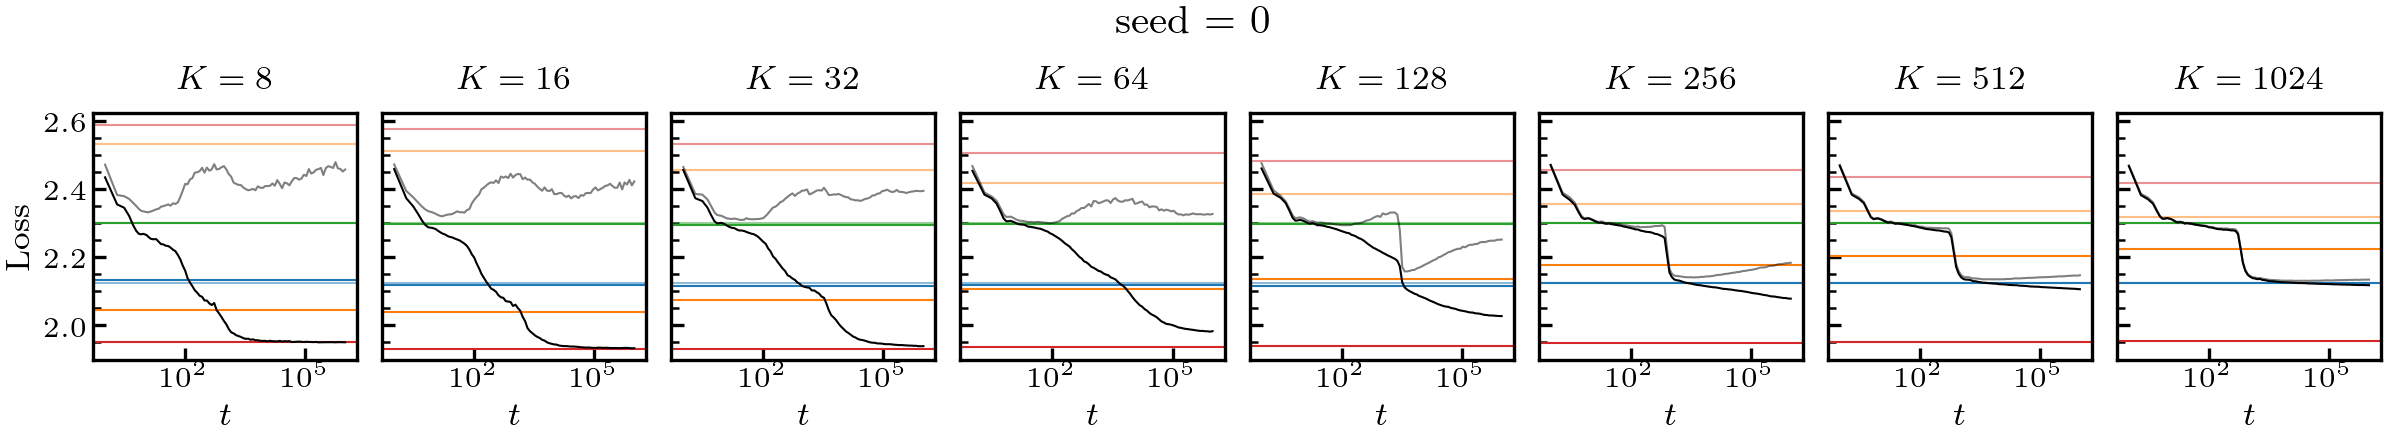

In [104]:
for seed_idx in range(n_seeds):
    fig, axes = plt.subplots(1, n_params, figsize = (1*n_params, 1.5), sharey = True, layout = 'constrained')
    for n_idx in range(n_n):
        for param_idx in range(n_params):
            ax = axes[param_idx]
            plot_loss(ax, mask_df(model_perf, exp_config, seed_idx, n_idx, param_idx, param_name), mask_df(est_perf, exp_config, seed_idx, n_idx, param_idx, param_name), exp_config, plot_kwargs={'linewidth': 0.5})
            ax.set_xscale('log')
    fig.suptitle(f'seed = {exp_config.seedrange[seed_idx]}')

Condensed figure

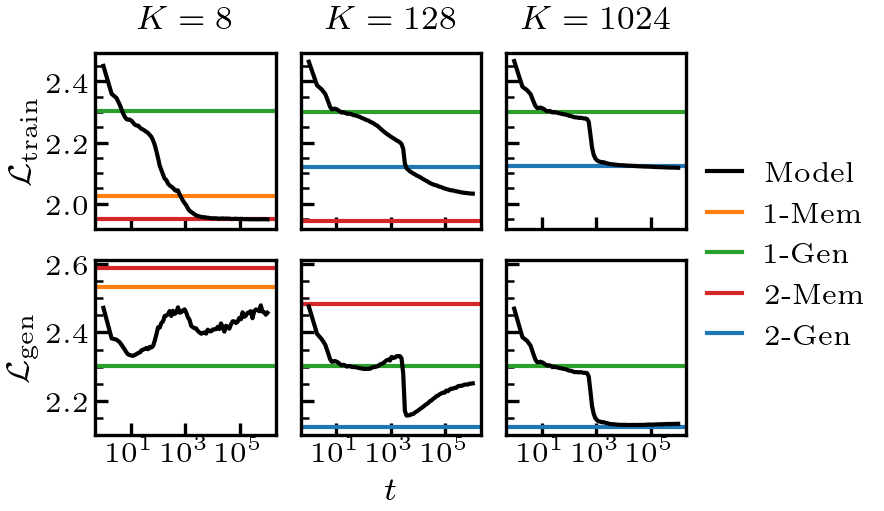

In [27]:
_param_idxs = [0, 4, -1]
_est_idxs = [[0, 1, 2], [1, 2, 3], [1, 3]]
_n_params = len(_param_idxs)
for seed_idx in [0]:
    fig, axes = plt.subplots(2, _n_params, figsize = (1*_n_params, 1.75), sharex=True, sharey='row', layout='constrained')
    for n_idx in range(n_n):
        for param_idx in range(_n_params):
            ax = axes[:, param_idx]
            est_idxs = _est_idxs[param_idx]
            param_idx = _param_idxs[param_idx]
            for i, dist in enumerate([['train'], ['val']]):
                plot_loss(
                    ax[i], 
                    mask_df(model_perf, exp_config, seed_idx, n_idx, param_idx, param_name), 
                    mask_df(est_perf, exp_config, seed_idx, n_idx, param_idx, param_name), 
                    exp_config, est_idx_list = est_idxs, dist = dist, alpha_val=1.0, plot_kwargs={'linewidth': 1})
                ax[i].set_xscale('log')

for idx, ax in enumerate(axes.flatten()):
    ax.set_ylabel('')
    ax.set_xticks([1e1, 1e3, 1e5])
    # ax.set_xlabel('')
    if idx > 2:
        ax.set_title('')
    if idx != 4:
        ax.set_xlabel('')

axes[0, 0].set_ylabel(r'$\mathcal{L}_\text{train}$')
axes[1, 0].set_ylabel(r'$\mathcal{L}_\text{gen}$')

# fig.supxlabel(r'$t$')

legend_handles = [
    mlines.Line2D([], [], color='black', linestyle='-', linewidth=1,label='Model'),
    mlines.Line2D([], [], color=sns.color_palette()[1], linestyle='-', linewidth=1, label='1-Mem'),
    mlines.Line2D([], [], color=sns.color_palette()[2], linestyle='-', linewidth=1, label='1-Gen'),
    mlines.Line2D([], [], color=sns.color_palette()[3], linestyle='-', linewidth=1, label='2-Mem'),
    mlines.Line2D([], [], color=sns.color_palette()[0], linestyle='-', linewidth=1, label='2-Gen'),
]

legend = fig.legend(legend_handles, ['Model', '1-Mem', '1-Gen', '2-Mem', '2-Gen'], loc="outside right", ncol=1)

plt.savefig(plot_dir / 'loss.svg', bbox_inches='tight')

### order params

In [15]:
order_params['2_seq'] = order_params['2_lt_entropy'].apply(lambda x: 2**(x-8))
order_params['1_seq'] = order_params['1_lt_entropy'].apply(lambda x: 2**(x-8))

### edge ablation

In [7]:
df = edge_causal.copy(deep = True)
mask = (df['ablated_edge'] != '(-1, -1)') & (df['ablated_edge'] != '()')
df = df[mask]

    # 0:        token                           0
    # 1, 0:     attention 1_Q    dest           1
    # 1, 1:     attention 1_K    dest           2
    # 1, 2:     attention 1_V    source         3
    # 2:        MLP                             4
    # 3, 0:     attention 2_Q    dest           5
    # 3, 1:     attention 2_K    dest           6
    # 3, 2, 0:  attention 2_V_0  ablate source  7
    # 3, 2, 1:  attention 2_V_1  ablate source  8
    # 3, 2, 2:  attention 2_V_2  ablate source  9
    # 3, 2:     attention 2_V    source         10
    # 4:        MLP                             11
    # 5:        unembed                         12

names = {
    0: 'Tok',
    1: 'Att1Q',
    2: 'Att1K',
    3: 'Att1V',
    4: 'MLP1',
    5: 'Att2Q',
    6: 'Att2K',
    7: 'Att2VTok',
    8: 'Att2VAtt1',
    9: 'Att2VMLP1',
    11: 'MLP2',
    12: 'Lin'
}

df['ablated_edge'] = df['ablated_edge'].apply(lambda x: ast.literal_eval(x))
df['from'] = df['ablated_edge'].apply(lambda x: names[x[0]])
df['to'] = df['ablated_edge'].apply(lambda x: names[x[1]])

# set ordering for convenience
to_order = ['Lin','MLP2','Att2K','Att2Q','MLP1', 'Att1K','Att1Q']
from_order = ['Tok','Att1V','MLP1','Att2VTok','Att2VAtt1','Att2VMLP1','MLP2','Lin']

df['from'] = pd.Categorical(df['from'], categories = from_order, ordered=True)
df['to'] = pd.Categorical(df['to'], categories=to_order, ordered=True)

df['logK'] = df['K'].apply(lambda x: np.log2(x))
# derivative wrt to t of 'kl_norm' grouping by seed, K, n, and ablated_edge
df['d_kl_norm'] = df.groupby(['seed', 'K', 'n', 'ablated_edge'])['kl_norm'].diff().fillna(0)

In [9]:
def circuit_plot(ax, t, K, name: str, show_xlabels=False, derivative=False):
    t, filtered_df = filter_t(df, t)
    mask = (filtered_df['K'] == K)
    if derivative:
        snapshot = filtered_df[mask].pivot_table(values='d_kl_norm', index='from', columns='to', observed=False)
        v = np.max(np.abs(snapshot))
        sns.heatmap(snapshot, cmap='vlag', center=0, vmin=-v, vmax=v, square=True, ax = ax, cbar=True)
    else:
        snapshot = filtered_df[mask].pivot_table(values='kl_norm', index='from', columns='to', observed=False)
        sns.heatmap(snapshot, cmap='Grays', vmin=0, vmax = 1, square=True, ax = ax, cbar=True, annot=False, fmt=".1f", annot_kws={"size": 6})
    ax.set_yticklabels(['State', 'Att1(State)', 'MLP1', 'Att2(State)', 'Att2(Att1)', 'Att2(MLP1)', 'MLP2'], rotation=0)
    ax.set_xticklabels(['Linear', 'MLP2', 'Att2K', 'Att2Q', 'MLP1', 'Att1K', 'Att1Q'], rotation=90)
    ax.tick_params(axis='both', which='both', length=0)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(name)
    ax.invert_xaxis()
    # cbar = ax.collections[0].colorbar
    # cbar.set_label(r"$D_{KL}(\hat\pi | \tilde\pi)$")

    if not show_xlabels:
        ax.set_xticklabels([])
        ax.set_xlabel("")

    # draw boxes
    data = snapshot.to_numpy()
    rows, cols = np.where(~np.isnan(data))
    for r, c in zip(rows, cols):
        ax.add_patch(Rectangle(
            (c, r),       # (x, y) in data coordinates (col, row)
            1, 1,
            fill=False,
            edgecolor="black",
            linewidth=0.5
        ))
    
    return snapshot

In [8]:
kl = pd.read_csv(Path(exp_config.base_dir) / 'kl.csv')
kl['mean'] = kl['train'] + kl['val']
kl['mean'] = kl['mean'] / 2

idx = kl.groupby(['K', 'n', 'seed', 'est_name'])['mean'].idxmin()
t_min_div = kl.loc[idx, ['K', 'n', 'seed', 'est_name', 't']].reset_index(drop=True)

1_gen
to              Lin  MLP2  Att2K  Att2Q      MLP1  Att1K  Att1Q
from                                                           
Tok             NaN   NaN    NaN    NaN       NaN    NaN    NaN
Att1V           NaN   NaN    NaN    NaN  1.090758    NaN    NaN
MLP1       0.429303   NaN    NaN    NaN       NaN    NaN    NaN
Att2VTok        NaN   NaN    NaN    NaN       NaN    NaN    NaN
Att2VAtt1       NaN   NaN    NaN    NaN       NaN    NaN    NaN
Att2VMLP1  0.292451   NaN    NaN    NaN       NaN    NaN    NaN
MLP2            NaN   NaN    NaN    NaN       NaN    NaN    NaN
1_mem
to              Lin      MLP2  Att2K  Att2Q      MLP1     Att1K    Att1Q
from                                                                    
Tok             NaN       NaN    NaN    NaN  1.904341  0.307332  0.29057
Att1V           NaN       NaN    NaN    NaN  2.581099       NaN      NaN
MLP1       0.606986  1.061926    NaN    NaN       NaN       NaN      NaN
Att2VTok        NaN       NaN    NaN    NaN    

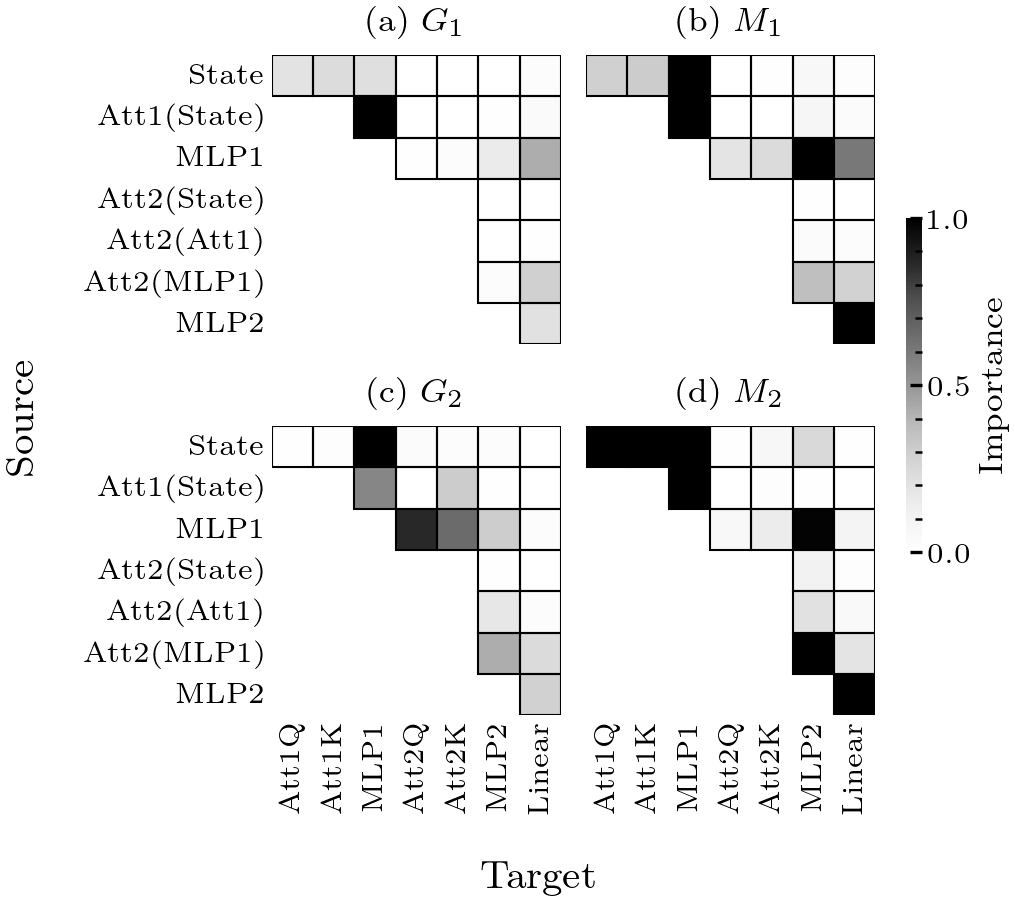

In [17]:
settings = [
    (-1, 0, 0, r'(a) $G_1$', '1_gen'),
    (4, 0, 0, r'(b) $M_1$', '1_mem'),
    (-1, 0, 0, r'(c) $G_2$', '2_gen'),
    (4, 0, 0, r'(d) $M_2$', '2_mem')
]

fig, axes = plt.subplots(
    2, 2,
    figsize=(3.375, 3),
    layout='constrained',
    sharey=True,
    sharex=True
)

mappable = None

for idx, ax in enumerate(axes.flatten()):
    param_idx, seed_idx, n_idx, title, name = settings[idx]
    seed, K, N = get_params(exp_config, seed_idx, param_idx, n_idx)
    t = t_min_div[
        t_min_div['K'].eq(K) & 
        t_min_div['est_name'].eq(name)
        ]['t'].values.item()
    snapshot = circuit_plot(ax, t, K, title, show_xlabels=(idx % 2 == 1))

    if mappable is None:
        mappable = ax.collections[0]
    ax.collections[0].colorbar.remove()

    print(name)
    print(snapshot[snapshot > 0.25])

# global colorbar
cbar = fig.colorbar(mappable, ax=axes, shrink=0.5)
cbar.outline.set_visible(False)
cbar.set_label('Importance')
cbar.set_ticks([0, 0.5, 1])

# Important: finalize constrained layout before reading geometry
fig.canvas.draw()

# Get the union of the subplot positions (excluding the colorbar)
flat_axes = axes.flatten()
x0 = min(ax.get_position().x0 for ax in flat_axes)
x1 = max(ax.get_position().x1 for ax in flat_axes)
y0 = min(ax.get_position().y0 for ax in flat_axes)
y1 = max(ax.get_position().y1 for ax in flat_axes)

x_center = 0.5 * (x0 + x1)
y_center = 0.5 * (y0 + y1)

# Place labels centered on the subplot block itself
fig.supylabel('Source', y=y_center, ha='center', va='center', rotation='vertical')
fig.supxlabel('Target', x=x_center, ha='center', va='center')

plt.savefig(plot_dir / 'afig_circuits_raw.svg', bbox_inches='tight')

### task vector

In [112]:
data_dir = dir / "data"
exp_config = u.load_config(dir / 'exp_config.yaml')
print(exp_config.notes)
exp_config.base_dir = exp_config.base_dir.replace('slot', 'shared')
exp_config.seedrange = exp_config.seedrange
exp_config.paramrange = exp_config.paramrange
n_seeds = len(exp_config.seedrange)
n_n = len(exp_config.nrange)
n_params = len(exp_config.paramrange)
param_name = exp_config.param_name

1 seed of phase diagram computations for 10^6 iterations


#### t-SNE

In [7]:
from base.operations.toolkit import get_res_act

def get_tv(param_idx, seed_idx, n_idx, t, B = 2**10):
    K = exp_config.paramrange[param_idx]

    get_model_safe = u.dynamic_import(exp_config.model, 'get_model_safe')
    get_task_model_safe = u.dynamic_import(exp_config.task_model, 'get_task_model_safe')
    model_name = naming(exp_config.seedrange[seed_idx], exp_config.nrange[n_idx], exp_config.param_name, K)

    config = u.load_config_and_task_pool(Path(exp_config.base_dir) / 'data' / model_name)
    model = get_model_safe(config)
    task_model = get_task_model_safe(config)
    model.eval()
    state_path = Path(exp_config.base_dir) / 'data' / model_name / 'state'
    state_idx = get_state_idx(config, state_path, t)
    state_dict = torch.load(state_path / f'{state_idx}.pt')
    s = state_dict['iter']
    print(f"Loaded state dict from iter {s} (t={t})")
    state_dict = state_dict['state']
    model.load_state_dict(state_dict)
    x, y, tasks = task_model.get_batch(B, config.training.context_len, return_tasks=True)
    xx, _ = task_model.get_batch(B, config.training.context_len, dist='val')
    task_pool = task_model.task_pool
    tv = get_res_act(model, (x, y))

    return tv, tasks[:, -1], task_model

In [8]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def tsne(data, labels, title, ax):
    # Convert to numpy
    x_np = data.detach().cpu().numpy()
    labels_np = labels.detach().cpu().numpy()

    # Run t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=30.0,
        learning_rate="auto",
        init="pca",
        random_state=0,
    )
    print(x_np.shape)
    print('beginning t-SNE...')
    x_2d = tsne.fit_transform(x_np)   # (B, 2)

    print('t-SNE completed, building plot...')
    # Build dataframe for seaborn
    df = pd.DataFrame({
        "tsne_1": x_2d[:, 0],
        "tsne_2": x_2d[:, 1],
        "label": labels_np.astype(int)
    })
    print('DataFrame for plotting created, plotting...')
    sns.scatterplot(
        data=df,
        x="tsne_1",
        y="tsne_2",
        hue="label",
        palette="tab20",
        s=3,
        alpha=0.8,
        edgecolor=None,
        ax = ax
    )
    
    ax.text(0.05, 0.05, title, ha='left', va='bottom', transform=ax.transAxes)
    ax.legend().remove()
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

In [9]:
def tv_tsne(param_idx, seed_idx, n_idx, t, name, ax, B = 2**10):
    u.set_seed(10)
    tv, tasks, _ = get_tv(param_idx, seed_idx, n_idx, t, B = B)
    data = tv[2][:, -1, :]
    tsne(data, tasks, name, ax)

Loaded state dict from iter 10000 (t=10000.0)
(1024, 64)
beginning t-SNE...
t-SNE completed, building plot...
DataFrame for plotting created, plotting...
Loaded state dict from iter 93260 (t=100000.0)
(1024, 64)
beginning t-SNE...
t-SNE completed, building plot...
DataFrame for plotting created, plotting...


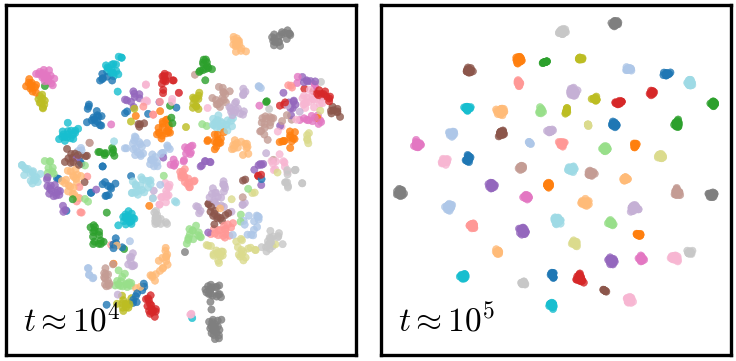

In [12]:
settings = [
    (3, 0, 0, 1e4),
    (3, 0, 0, 1e5),
]

fig, axes = plt.subplots(1, len(settings), figsize=(1.25*len(settings), 1.25), sharey=True, layout='constrained')



mpl.rcParams.update({
    # for running on nodes without latex
    "text.usetex": False,
})

for idx, ax in enumerate(axes):
    param_idx, seed_idx, n_idx, t = settings[idx]
    name = rf"$t\approx10^{{{int(math.log10(t))}}}$"
    output = tv_tsne(param_idx, seed_idx, n_idx, t, name, ax)
plt.savefig(plot_dir / 'tv_tsne.svg')

mpl.rcParams.update({
    # for running on nodes without latex
    "text.usetex": True,
})

#### patching

In [31]:
def accuracy(logits1, logits2):
    assert logits1.shape == logits2.shape
    n = logits1.shape[0]
    p1 = F.softmax(logits1, -1)
    p2 = F.softmax(logits2, -1)
    _, idx1 = p1.max(-1)
    _, idx2 = p2.max(-1)

    return (torch.sum(idx1 == idx2)/n).item()

def similarity(logits1, logits2):
    assert logits1.shape == logits2.shape
    
    return math.exp(-u.KL(logits1, logits2)/u.KL(logits1, torch.zeros_like(logits1)))
    # return 1 - KL(logits1, logits2)/KL(logits1, torch.zeros_like(logits1))

In [30]:
from pd.compute import naming
from base.estimators.markov_model_ar import BiMem, UniMem
from base.operations.toolkit import get_res_act, patched_res_act_performance
from matplotlib import patches as mpatches

def perturb_plot(ax, seed_idx, n_idx, param_idx, t, name: str, estimator: str, attn_idx: int, minimal = False):
    u.set_seed(10)
    K = exp_config.paramrange[param_idx]

    get_model_safe = u.dynamic_import(exp_config.model, 'get_model_safe')
    get_task_model_safe = u.dynamic_import(exp_config.task_model, 'get_task_model_safe')
    model_name = naming(exp_config.seedrange[seed_idx], exp_config.nrange[n_idx], exp_config.param_name, K)

    config = u.load_config_and_task_pool(Path(exp_config.base_dir) / 'data' / model_name)
    model = get_model_safe(config)
    task_model = get_task_model_safe(config)
    model.eval()
    state_path = Path(exp_config.base_dir) / 'data' / model_name / 'state'
    state_idx = get_state_idx(config, state_path, t)
    state_dict = torch.load(state_path / f'{state_idx}.pt')
    s = state_dict['iter']
    state_dict = state_dict['state']
    model.load_state_dict(state_dict)
    B = 2**10
    N = exp_config.nrange[n_idx]
    xa, ya, tasks = task_model.get_batch(B, config.training.context_len, return_tasks=True)
    xb, yb = task_model.get_batch(B, config.training.context_len)
    if estimator == '2_mem':
        estimator = BiMem(config, task_model.task_pool.float(), task_model.stat_dist.float())
    elif estimator == '1_mem':
        estimator = UniMem(config, task_model.task_pool.float(), task_model.stat_dist.float())
    
    # (x, y) = posterior on x, predict on current states of y
    behavior = {}
    behavior['AA'], _, hatTa = estimator(xa, ya, return_hatT=True)
    behavior['BB'], _, hatTb = estimator(xb, yb, return_hatT=True)
    behavior['AB'] = torch.log(torch.einsum('ijkl,ijk->ijl', hatTa, F.one_hot(xb, config.task.vocab_size).float()))
    behavior['BA'] = torch.log(torch.einsum('ijkl,ijk->ijl', hatTb, F.one_hot(xa, config.task.vocab_size).float()))

    a_logits, _ = model(xa, ya)
    b_logits, _ = model(xb, yb)
    a_tv = get_res_act(model, (xa, ya))
    b_tv = get_res_act(model, (xb, yb))

    output = {
        'predictor': [],
        'accuracy': [],
        'condition': [],
        'similarity': [],
    }
    
    bpa_logits, _ = patched_res_act_performance(model, [attn_idx], [a_tv[attn_idx]], (xb, yb))
    apb_logits, _ = patched_res_act_performance(model, [attn_idx], [b_tv[attn_idx]], (xa, ya))
    for key in behavior.keys():
        t = behavior[key]

        output['similarity'].append(similarity(t.flatten(0,1), a_logits))
        output['accuracy'].append(accuracy(t.flatten(0,1), a_logits))
        output['predictor'].append(key)
        output['condition'].append('SeqA')

        output['similarity'].append(similarity(t.flatten(0,1), b_logits))
        output['accuracy'].append(accuracy(t.flatten(0,1), b_logits))
        output['predictor'].append(key)
        output['condition'].append('SeqB')

        output['similarity'].append(similarity(t.flatten(0,1), bpa_logits))
        output['accuracy'].append(accuracy(t.flatten(0,1), bpa_logits))
        output['predictor'].append(key)
        output['condition'].append('SeqB (Patch A)')

        output['similarity'].append(similarity(t.flatten(0,1), apb_logits))
        output['accuracy'].append(accuracy(t.flatten(0,1), apb_logits))
        output['predictor'].append(key)
        output['condition'].append('SeqA (Patch B)')
    
    output = pd.DataFrame(output)

    baseline_similarity = similarity(t.flatten(0,1), torch.zeros_like(apb_logits))  # unconditioned baseline

    if minimal:
        plot_data = output[output['condition'].isin(['SeqA', 'SeqB (Patch A)']) & output['predictor'].isin(['AA', 'AB'])].copy()
    else:
        plot_data = output.copy()

    if minimal:
        hue_order = ['SeqA', 'SeqB (Patch A)']
        hatches = ['', '']
    else:
        hue_order = ['SeqA', 'SeqB', 'SeqB (Patch A)', 'SeqA (Patch B)']
        hatches = ['/', '\\\\', 'xx', '..']

    sns.barplot(
        data=plot_data,
        x='predictor',
        y='similarity',
        hue='condition',
        hue_order=hue_order,
        ax=ax,
        legend=True,
        palette=['C7', 'white'],
        edgecolor='black',
    )

    # for i, bar in enumerate(ax.patches):
    #     bar.set_facecolor('white' if i // 2 ==1 else 'black')
    #     bar.set_edgecolor('black')
    #     # bar.set_hatch(hatches[i % len(hue_order)])

    # legend_handles = [
    #     mpatches.Patch(facecolor='black', edgecolor='white', hatch=h, label=label)
    #     for h, label in zip(hatches, hue_order)
    # ]
    # ax.legend(handles=legend_handles, title='condition')
    # sns.barplot(data = plot_data, x = 'predictor', y = 'similarity', hue='condition', ax = ax, legend=True, palette=['C6', 'C9', 'C6', 'C9'])
    # ax.set_title(f'{name} Task Vector Patching')
    ax.set_xlabel('Predictor')
    ax.set_ylabel('Similarity')
    # ax.axhline(baseline_similarity, color='black', linestyle=':', label='Uniform Baseline')
    
    return output, behavior, ax, s

State file /scratch/gpfs/GREDDY/cg5763/output/gentle_anaconda/data/S0_N256_K32/state/92.pt does not exist. Returning last valid index 91.
999999


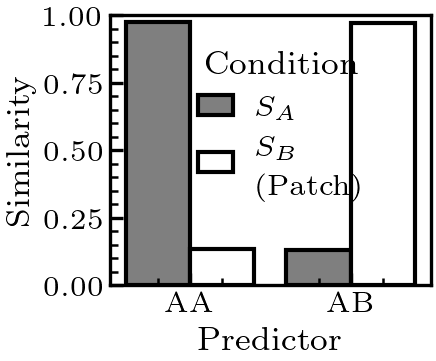

In [10]:
settings = [
    (2, 0, 0, 1e6, r'2-Mem')
]

fig, axes = plt.subplots(1, len(settings), figsize=(1.5, 1.25), layout='constrained', sharey=True)
axes = [axes]

for idx, ax in enumerate(axes):
    param_idx, seed_idx, n_idx, t, name = settings[idx]
    output, behavior, ax, s = perturb_plot(ax, seed_idx, n_idx, param_idx, t, name, '2_mem', attn_idx=2, minimal=True)
    print(s)
handles, labels = ax.get_legend_handles_labels()

for ax in axes:
    ax.legend_.remove()

fig.legend(handles, [r'$S_A$', r'\raisebox{-1.7ex}{\shortstack[l]{$S_B$\\(Patch)}}'], loc='upper center', ncol=1, frameon=False, title='Condition', fontsize=7, title_fontsize=8, bbox_to_anchor=(0.64, 0.9))
for ax in axes:
    ax.set_ylim(0, 1)

plt.savefig(plot_dir / 'tv_patch.svg', bbox_inches='tight')

2477


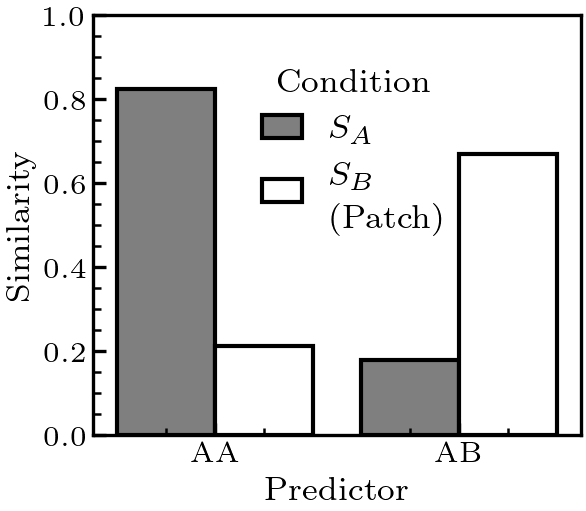

In [53]:
settings = [
    (2, 0, 0, 2477, r'1-Mem')
]

fig, axes = plt.subplots(1, len(settings), figsize=(2, 1.75), layout='constrained', sharey=True)
axes = [axes]

for idx, ax in enumerate(axes):
    param_idx, seed_idx, n_idx, t, name = settings[idx]
    output, behavior, ax, s = perturb_plot(ax, seed_idx, n_idx, param_idx, t, name, '1_mem', attn_idx=0, minimal=True)
    print(s)
handles, labels = ax.get_legend_handles_labels()

for ax in axes:
    ax.legend_.remove()

fig.legend(handles, [r'$S_A$', r'\raisebox{-1.7ex}{\shortstack[l]{$S_B$\\(Patch)}}'], loc='upper center', ncol=1, frameon=False, title='Condition', fontsize=8, title_fontsize=8, bbox_to_anchor=(0.6, 0.9))
for ax in axes:
    ax.set_ylim(0, 1)

plt.savefig(plot_dir / 'afig_tv_patch.svg', bbox_inches='tight')

#### mutual information

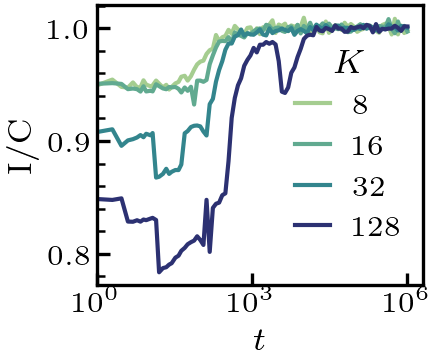

In [12]:
settings = [
    (0, 0, 0, 0),
    (1, 0, 0, 0),
    (2, 0, 0, 0),
    # (3, 0, 0, 0),  # second index read directly as seed, last index for dir
    (4, 0, 0, 0),
    # (4, 1, 0, 1),
]

dirlist = [
    Path('~/data/output/gentle_anaconda').expanduser(),
]

bigram_embd = []
for setting in settings:
    param_idx, seed, n_idx, dir_idx = setting
    _bigram_embd=pd.read_csv(Path(dirlist[dir_idx]) / 'data' / f'S{seed}_N{exp_config.nrange[n_idx]}_K{exp_config.paramrange[param_idx]}_bigram_embd.csv')
    bigram_embd.append(_bigram_embd)

bigram_embd = pd.concat(bigram_embd, ignore_index=False)
# bigram_embd = bigram_embd[bigram_embd['K'].ne(2**6)]
bigram_embd['logK'] = bigram_embd['K'].apply(lambda x: math.log2(x))
bigram_embd['mut_info_renorm'] = bigram_embd['mutual_information'] / bigram_embd['logK']

fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.25), layout='constrained', sharex=True)

ax = sns.lineplot(bigram_embd, x = 't', y = 'mut_info_renorm', hue = 'logK', estimator='mean', errorbar=None, palette = 'crest', ax=ax)
legend_handles, _ = ax.get_legend_handles_labels()
ax.legend(handles = legend_handles, labels = ['8', '16', '32', '128'], title=r'$K$', loc='center right')
ax.set_xscale('log')
ax.set_xlim(left=1)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'I/C')
plt.savefig(plot_dir / 'bigram_info.svg', bbox_inches='tight')

### phases

In [22]:
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from matplotlib import colormaps

def black_to_color(name=None, final_color=None, N=256, reverse=True):
    """
    Return a colormap that goes between black and a target color.

    Parameters
    ----------
    name : str, optional
        Name of a Matplotlib colormap (e.g. 'Reds'). Used if final_color is None.
    final_color : str or tuple, optional
        The final color (matplotlib-recognized format). If None, take from colormap.
    N : int
        Number of levels in the colormap.
    reverse : bool
        If True, make the gradient go from the target color to black.
    """
    if final_color is None:
        if name is None:
            raise ValueError("Either `name` or `final_color` must be provided.")
        base = colormaps.get_cmap(name)
        target = base(1.0)  # brightest color
    else:
        target = to_rgba(final_color)  # convert to RGBA

    colors = [(0, 0, 0, 1), target]
    if reverse:
        colors = colors[::-1]

    cmap = LinearSegmentedColormap.from_list(
        (name or "custom") + "_black" + ("_rev" if reverse else ""),
        colors,
        N=N
    )
    return cmap

def log_heatmap(pvt, ax=None, vmin=None, vmax=None, cmap="viridis", rasterized=True):
    if ax is None:
        ax = plt.gca()

    X = np.asarray(pvt.columns, dtype=float)
    Y = np.asarray(pvt.index, dtype=float)
    Z = pvt.values

    def log_edges(vals):
        vals = np.asarray(vals, float)
        ratios = vals[1:] / vals[:-1]
        edges = np.empty(len(vals) + 1)
        edges[1:-1] = np.sqrt(vals[:-1] * vals[1:])
        edges[0] = vals[0] / np.sqrt(ratios[0])
        edges[-1] = vals[-1] * np.sqrt(ratios[-1])
        return edges

    x_edges = log_edges(X)
    y_edges = log_edges(Y)

    qm = ax.pcolormesh(
        x_edges, y_edges, Z,
        shading="auto",
        vmin=vmin, vmax=vmax, cmap=cmap,
        edgecolors="none",
        linewidth=0,
        antialiased=False,
        rasterized=rasterized,   # <-- key
    )

    ax.set_xscale("log")
    ax.set_yscale("log", base=2)

    for spine in ax.spines.values():
        spine.set_visible(False)

    return ax, qm

import numpy as np
import matplotlib.pyplot as plt

def composite_cmap_colorbar(
    fig,
    colors,
    *,
    vmin,
    vmax,
    ax_rect=(1.05, 0.2, 0.025, 0.7),   # (x, y, w_per_cmap, h) in figure coords
    n=256,                             # vertical resolution
    ticks=None,
    tick_right=True,
    label="",
    remove_spines=True,
    separator=True,
    separator_kwargs=None,
    cmap_factory=None,                 # function(color)->cmap; defaults to black_to_color(final_color=color)
):
    """
    Draw a composite vertical "colorbar" consisting of adjacent columns, one per colormap,
    all sharing the same [vmin, vmax] normalization.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
    colors : sequence
        Sequence of colors (any matplotlib-acceptable color objects).
    vmin, vmax : float
    ax_rect : (x, y, w_per_cmap, h)
        Rectangle in figure coordinates. Width is per-colormap; total width scales with len(colors).
    n : int
        Number of samples along the vertical axis.
    ticks : sequence or None
        Y ticks in data units. If None, no ticks are set.
    tick_right : bool
        Place y ticks on the right.
    label : str
        Optional y-axis label (acts like a colorbar label).
    remove_spines : bool
        Hide all spines.
    separator : bool
        Draw vertical separators between columns.
    separator_kwargs : dict or None
        Passed to ax.vlines; defaults to thin white separators.
    cmap_factory : callable or None
        If provided, called as cmap_factory(color) -> matplotlib Colormap.
        If None, uses black_to_color(final_color=color).

    Returns
    -------
    ax : matplotlib.axes.Axes
    """
    if cmap_factory is None:
        def cmap_factory(c):
            return black_to_color(final_color=c)

    x, y, w_per, h = ax_rect
    k = len(colors)
    if k == 0:
        raise ValueError("colors must be a non-empty sequence.")

    ax = fig.add_axes([x, y, w_per * k, h])

    values = np.linspace(vmin, vmax, n)[:, None]  # (n, 1)
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for i, c in enumerate(colors):
        ax.imshow(
            values,
            cmap=cmap_factory(c),
            norm=norm,
            aspect="auto",
            origin="lower",
            extent=(i, i + 1, vmin, vmax),
        )

    ax.set_xlim(0, k)
    ax.set_ylim(vmin, vmax)
    ax.set_xticks([])

    if ticks is not None:
        ax.set_yticks(list(ticks))

    if tick_right:
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

    if label:
        ax.set_ylabel(label)

    if remove_spines:
        for spine in ax.spines.values():
            spine.set_visible(False)

    if separator and k > 1:
        if separator_kwargs is None:
            separator_kwargs = dict(colors="white", linewidth=0.5)
        ax.vlines(np.arange(1, k), vmin, vmax, **separator_kwargs)

    return ax

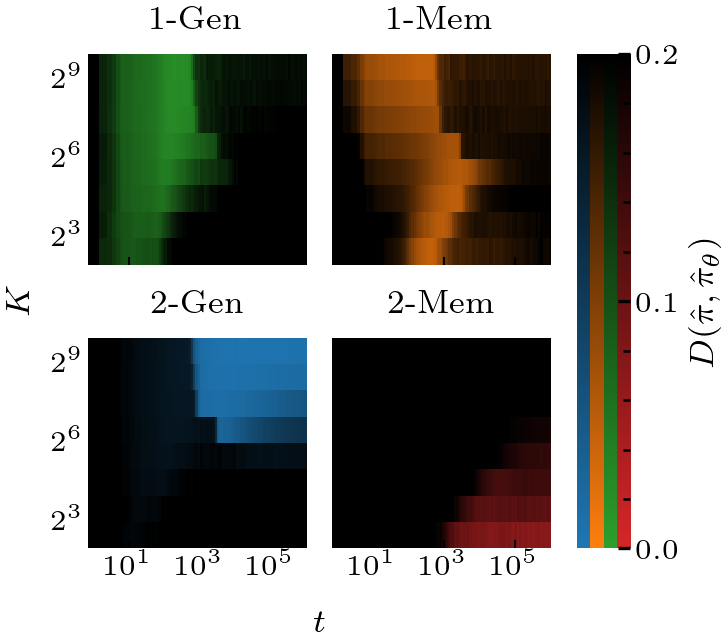

In [23]:
fig, axes = plt.subplots(2, 2, figsize = (1.75, 2), sharex = True, sharey = True, layout = 'constrained')
kl = pd.read_csv(Path(exp_config.base_dir) / 'kl.csv')
kl['logt'] = kl['t'].apply(lambda x: np.log10(x))
kl['logk'] = kl['K'].apply(lambda x: np.log2(x))
kl['mean'] = kl['train'] + kl['val']
kl['mean'] = kl['mean'] / 2
order_params['logt'] = order_params['t'].apply(lambda x: np.log10(x))

cbar = False
gen_values = 'mean'
mem_values = 'mean'

vmax = 0.2
vmin = 0
ax, qm = log_heatmap(kl[kl["est_name"] == "2_gen"].pivot_table(index = 'K', columns = 't', values = gen_values), vmin = vmin, vmax = vmax, ax = axes[1, 0], cmap = black_to_color(final_color = sns.color_palette()[0]))
ax.set_title(r'$2$-Gen')
ax, qm = log_heatmap(kl[kl["est_name"] == "1_gen"].pivot_table(index = 'K', columns = 't', values = gen_values), vmin = vmin, vmax = vmax, ax = axes[0, 0], cmap = black_to_color(final_color = sns.color_palette()[2]))
ax.set_title(r'$1$-Gen')
ax, qm = log_heatmap(kl[kl["est_name"] == "2_mem"].pivot_table(index = 'K', columns = 't', values = mem_values), vmin = vmin, vmax = vmax, ax = axes[1, 1], cmap = black_to_color(final_color = sns.color_palette()[3]))
ax.set_title(r'$2$-Mem')
ax, qm = log_heatmap(kl[kl["est_name"] == "1_mem"].pivot_table(index = 'K', columns = 't', values = mem_values), vmin = vmin, vmax = vmax, ax = axes[0, 1], cmap = black_to_color(final_color = sns.color_palette()[1]))
ax.set_title(r'$1$-Mem')
# ax = log_heatmap(order_params.pivot_table(index = 'K', columns = 't', values = 'pta'), ax = axes[-1, 1], vmin = 0, vmax = 1, cmap = 'rocket')
# ax.set_title('Previous Token')
# ax = log_heatmap(order_params.pivot_table(index = 'K', columns = 't', values = 'iha_tot'), ax = axes[-1, 0], vmin = 0, vmax = 1, cmap = 'rocket')
# ax.set_title('Induction Head')

# force figure draw
fig.canvas.draw()

for ax in axes.flat:
    ax.set_xticklabels(list())
    ax.set_yticklabels(list())
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.tick_params(axis="both", which="major", length=2, width=0.5)

# get geometry

boxes = [ax.get_position() for ax in axes.flat]
left = min(b.x0 for b in boxes)
right = max(b.x1 for b in boxes)
bottom = min(b.y0 for b in boxes)
top = max(b.y1 for b in boxes)

# colorbar geometry relative to subplot block
pad = 0.05
cbar_width = 0.025
cbar_rect = (right + pad, bottom, cbar_width, top - bottom)

colors = sns.color_palette()[:4]  # arbitrary length
cax = composite_cmap_colorbar(
    fig,
    colors,
    vmin=vmin,
    vmax=vmax,
    ticks=[vmin, vmax/2, vmax],
    ax_rect=cbar_rect,
    separator=False,
    label=r'$D(\hat{\pi}, \hat{\pi}_\theta)$'
)

xticks = [1, 3, 5]
xlabels = [rf'$10^{tick}$' for tick in xticks]
xticks = [10**t for t in xticks]
for ax in axes[-1, :].flat:
    # ax.set_xlabel(r'$t$')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)

yticks = [3, 6, 9]
ylabels = [rf'$2^{t}$' for t in yticks]
yticks = [(2**t+2**(t+1))/2 for t in yticks]
for ax in axes[:, :-1].flat:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, rotation = 0)
    ax.tick_params(axis='y', rotation=0)

# centered labels
boxes = [ax.get_position() for ax in axes.flat]
left = min(b.x0 for b in boxes)
right = max(b.x1 for b in boxes)
bottom = min(b.y0 for b in boxes)

xcenter = 0.5 * (left + right)
ycenter = 0.5 * (bottom + top)

fig.text(xcenter, bottom - 0.1, r'$t$', ha='center', va='top')
fig.text(left - 0.1, 0.5 * (min(b.y0 for b in boxes) + max(b.y1 for b in boxes)),
         r'$K$', ha='right', va='center', rotation='vertical')

# fig.supxlabel(r'$t$', x=xcenter, ha='center')
# fig.supylabel(r'$K$', y=ycenter, rotation=0, va='center')


plt.savefig(plot_dir / 'phases.svg', bbox_inches = 'tight', dpi=300)

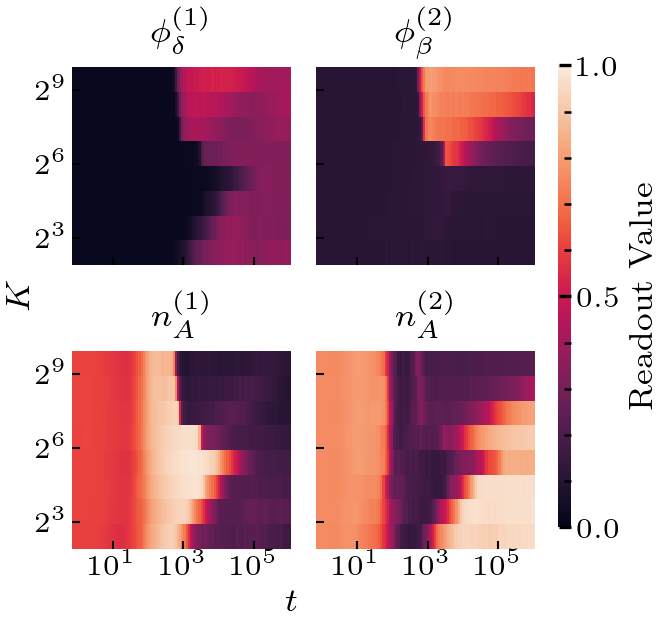

In [24]:
fig, axes = plt.subplots(2, 2, figsize = (1.75, 2), sharex = True, sharey = True, layout = 'constrained')
kl = pd.read_csv(Path(exp_config.base_dir) / 'kl.csv')
kl['logt'] = kl['t'].apply(lambda x: np.log10(x))
kl['logk'] = kl['K'].apply(lambda x: np.log2(x))
kl['mean'] = kl['train'] + kl['val']
kl['mean'] = kl['mean'] / 2
order_params['logt'] = order_params['t'].apply(lambda x: np.log10(x))

cbar = False

ax, qm = log_heatmap(order_params.pivot_table(index = 'K', columns = 't', values = 'pta'), ax = axes[0, 0], vmin = 0, vmax = 1, cmap = 'rocket')
ax.set_title(r'$\phi_\delta^{(1)}$')
ax, qm = log_heatmap(order_params.pivot_table(index = 'K', columns = 't', values = 'iha_tot'), ax = axes[0, 1], vmin = 0, vmax = 1, cmap = 'rocket')
ax.set_title(r'$\phi_\beta^{(2)}$')
ax, qm = log_heatmap(order_params.pivot_table(index = 'K', columns = 't', values = '1_seq'), ax = axes[-1, 0], vmin = 0, vmax = 1, cmap = 'rocket')
ax.set_title(r'$n_A^{(1)}$')
ax, qm = log_heatmap(order_params.pivot_table(index = 'K', columns = 't', values = '2_seq'), ax = axes[-1, 1], vmin = 0, vmax = 1, cmap = 'rocket')
ax.set_title(r'$n_A^{(2)}$')

for ax in axes.flat:
    ax.set_xticklabels(list())
    ax.set_yticklabels(list())
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.tick_params(axis="both", which="major", length=2, width=0.5)

# compute geometry
boxes = [ax.get_position() for ax in axes.flat]
left = min(b.x0 for b in boxes)
right = max(b.x1 for b in boxes)
bottom = min(b.y0 for b in boxes)
top = max(b.y1 for b in boxes)

# colorbar geometry relative to subplot block
pad = 0.12
cbar_width = 0.025
cbar_rect = (right + pad, bottom, cbar_width, top - bottom)

# make figure colorbar and place outside on the right of the subplots
cbar_ax = fig.add_axes(cbar_rect)  # x, y, width, height
norm = plt.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap='rocket', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.outline.set_visible(False)
cbar.set_ticks([0, 0.5, 1])
cbar.set_label('Readout Value')

xticks = [1, 3, 5]
xlabels = [rf'$10^{tick}$' for tick in xticks]
xticks = [10**t for t in xticks]
for ax in axes[-1, :].flat:
    # ax.set_xlabel(r'$t$')
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)

yticks = [3, 6, 9]
ylabels = [rf'$2^{t}$' for t in yticks]
yticks = [(2**t+2**(t+1))/2 for t in yticks]
for ax in axes[:, :-1].flat:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels, rotation = 0)
    ax.tick_params(axis='y', rotation=0)

# centered labels
xcenter = 0.5 * (left + right)

fig.text(xcenter, bottom - 0.1, r'$t$', ha='center', va='top')
fig.text(left - 0.1, 0.5 * (min(b.y0 for b in boxes) + max(b.y1 for b in boxes)),
         r'$K$', ha='right', va='center', rotation='vertical')

plt.savefig(plot_dir / 'order_params.svg', bbox_inches = 'tight', dpi=300)

# K1*

## N = 2^8

### loading

In [6]:
directories = [
    # Path("/mnt/shared/home/output/vicarious_mule"),
    # Path("/mnt/shared/home/output/frantic_chickadee"), # vary all seeds
    # Path("/mnt/shared/home/output/frail_newt"),   # fix task seed
    # Path("/mnt/shared/home/output/actual_sheep"),
    Path("/home/cg5763/data/output/natural_vulture"), # fix task seed, linear search
]
order_params = []
model_perf = []
search_kmin = {}
for dir in directories:
    data_dir = dir / "data"
    exp_config = u.load_config(dir / 'exp_config.yaml')
    search_kmin[exp_config.nrange[0]] = exp_config.paramrange[0]
    print(exp_config.notes)
    n_seeds = len(exp_config.seedrange)
    n_n = len(exp_config.nrange)
    n_params = len(exp_config.paramrange)
    param_name = exp_config.param_name
    for seed in exp_config.seedrange:
        for n in exp_config.nrange:
            for param_value in exp_config.paramrange:
                try:
                    order_params.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_order_params.csv'))
                    model_perf.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_model_perf.csv'))
                except FileNotFoundError:
                    print(f'File not found: S{seed}_N{n}_{param_name}{param_value}_order_params.csv')
                    continue
order_params = pd.concat(order_params, ignore_index = True)
model_perf = pd.concat(model_perf, ignore_index = True)

t_bigen kinetics near k1* at N = 2^8, fixed task seed, linear K search


Text(0, 0.5, '$K_1^*$')

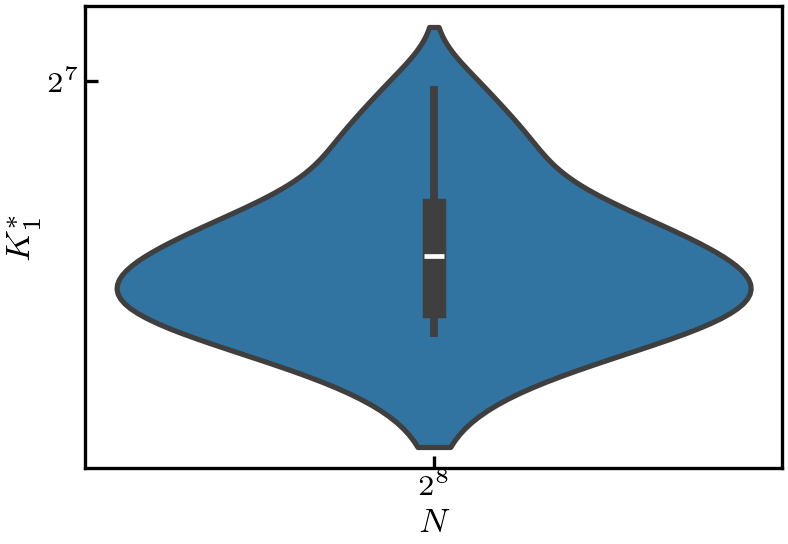

In [7]:
result = (
    order_params
    .groupby(["K", "seed", "n"])["iha_tot"]
    .max()
    .reset_index()
    .rename(columns={'iha_tot': 'max_iha_tot'})
)

k1 = (
    result[result['max_iha_tot'] > 0.45]
    .groupby(["seed", "n"])['K']
    .min()
    .reset_index()
    .rename(columns={'K': 'K1*'})
)

ax = sns.violinplot(k1, x = 'n', y = 'K1*', native_scale = True)
def pl(x, a, b):
    return a*x**b
# params, _ = curve_fit(pl, list(k1['n']), list(k1['K1*']), maxfev = int(1e5))
# x = np.logspace(7, 11, base  = 2)
# y = map(lambda x: params[0]*x**params[1], x)
# sns.lineplot(x = x, y = y, color = 'orange', linestyle = ':', label = rf'$\propto N^{{{params[1]:.2f}}}$')
ax.set_xscale('log', base=2)
ax.set_yscale('log', base=2)
ax.set_xlabel(r'$N$')
ax.set_ylabel(r'$K_1^*$')

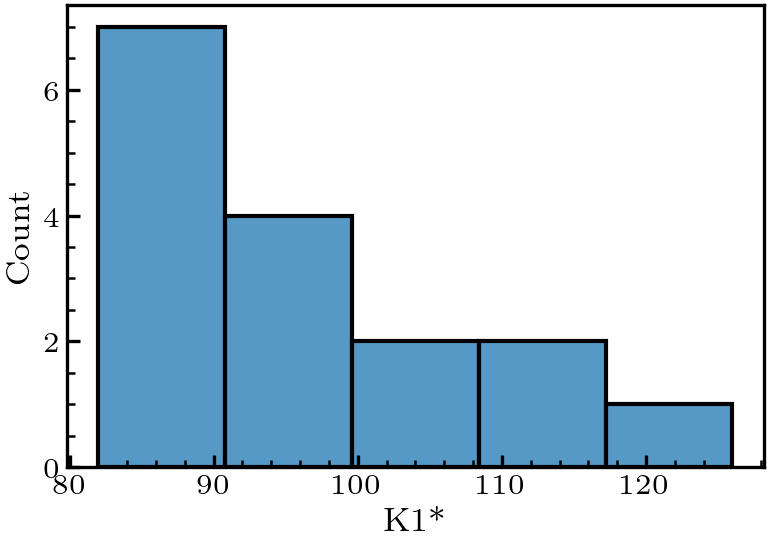

In [8]:
ax = sns.histplot(k1['K1*'], stat='count')

In [9]:
min_val = (
    model_perf[model_perf['dist'].eq('val')]
    .groupby(["K", "seed", "n"])["loss"]
    .min()
    .reset_index()
    .rename(columns={'loss': 'min_val'})
)

merged_df = (
    k1
    .merge(min_val, on=['seed', 'n'], how='left')
    .merge(result, on=['seed', 'n', 'K'], how='left')
)
merged_df['K_diff'] = merged_df['K'] - merged_df['K1*']
merged_df['K_diff_median'] = merged_df['K'] - merged_df['K1*'].median()
merged_df['K_norm_median'] = merged_df['K'] / merged_df['K1*'].median()

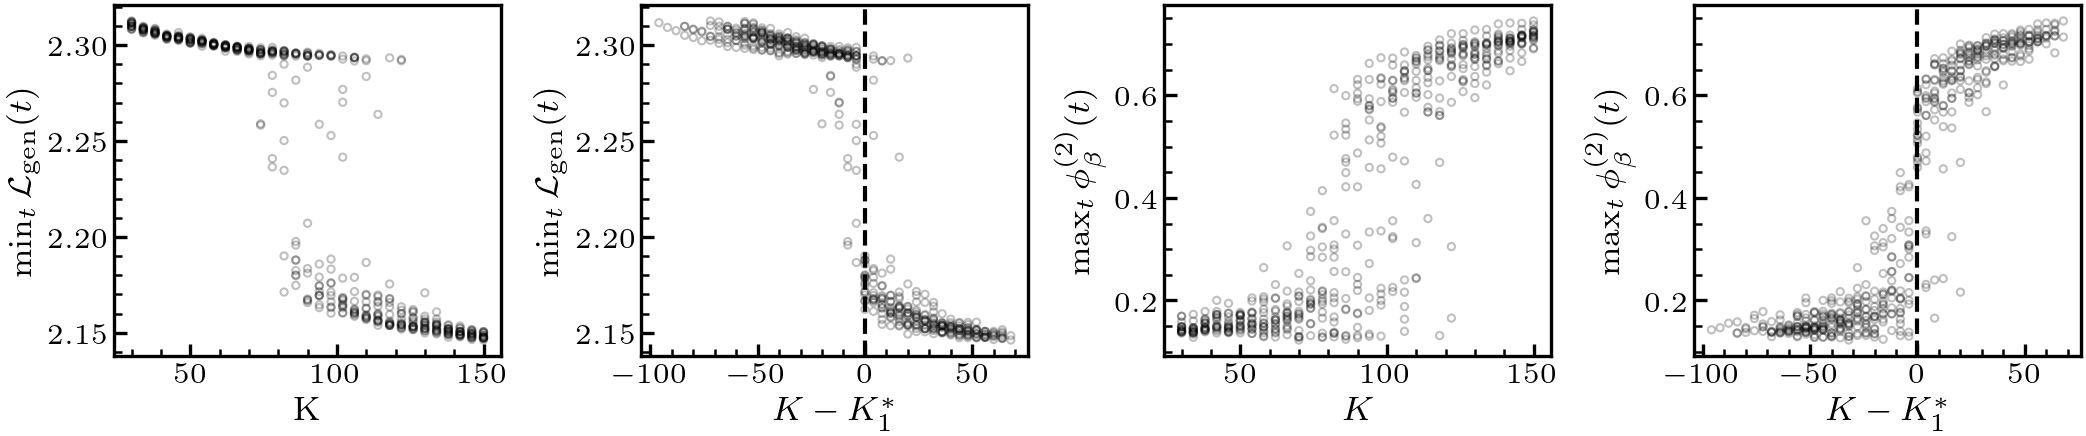

In [12]:
fig, axes = plt.subplots(
    1, 4,
    figsize=(4*1.75, 1.5),
    layout='constrained',
)

axes = axes.reshape(2, 2)

# absolute K
sns.scatterplot(
    data=merged_df,
    x='K',
    y='min_val',
    marker='o',
    facecolors='none',
    edgecolor='black',
    alpha=0.25,
    linewidth=0.5,
    s=3,
    ax=axes[0,0]
)

sns.scatterplot(
    data=merged_df,
    x='K',
    y='max_iha_tot',
    marker='o',
    facecolors='none',
    edgecolor='black',
    alpha=0.25,
    linewidth=0.5,
    s=3,
    ax=axes[1,0]
)

# relative K
sns.scatterplot(
    data=merged_df,
    x='K_diff',
    y='min_val',
    marker='o',
    facecolors='none',
    edgecolor='black',
    alpha=0.25,
    linewidth=0.5,
    s=3,
    ax=axes[0,1]
)

sns.scatterplot(
    data=merged_df,
    x='K_diff',
    y='max_iha_tot',
    marker='o',
    facecolors='none',
    edgecolor='black',
    alpha=0.25,
    linewidth=0.5,
    s=3,
    ax=axes[1,1]
)


axes[0,0].set_ylabel(r'$\min_t \mathcal{L}_\mathrm{gen}(t)$')
axes[1,0].set_ylabel(r'$\max_t \phi_\beta^{(2)}(t)$')
axes[1,0].set_xlabel(r'$K$')

axes[0,1].set_ylabel(r'$\min_t \mathcal{L}_\mathrm{gen}(t)$')
axes[1,1].set_ylabel(r'$\max_t \phi_\beta^{(2)}(t)$')
axes[1,1].set_xlabel(r'$K-K_1^*$')
axes[0,1].set_xlabel(r'$K-K_1^*$')

axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)
# x_max = max(abs(merged_df['K_diff'].min()), merged_df['K_diff'].max())
# axes[1,1].set_xlim(-x_max, x_max)


plt.savefig(plot_dir / 'k1_phi_beta.svg')

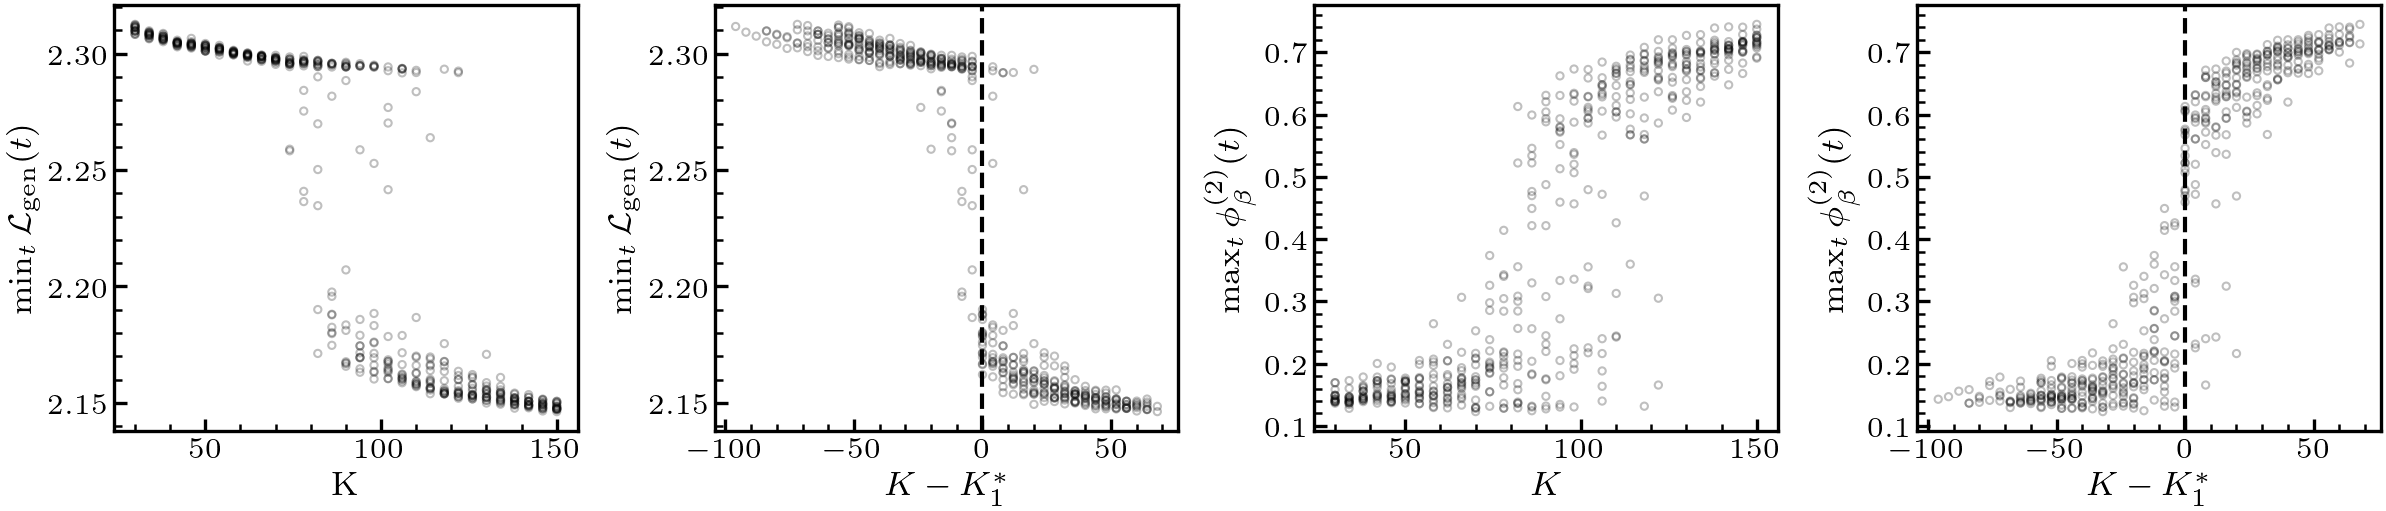

In [10]:
fig, axes = plt.subplots(
    1, 4,
    figsize=(4*2, 1.75),
    layout='constrained',
)

axes = axes.reshape(2, 2)

# absolute K
sns.scatterplot(
    data=merged_df,
    x='K',
    y='min_val',
    marker='o',
    facecolors='none',
    edgecolor='black',
    alpha=0.25,
    linewidth=0.5,
    s=3,
    ax=axes[0,0]
)

sns.scatterplot(
    data=merged_df,
    x='K',
    y='max_iha_tot',
    marker='o',
    facecolors='none',
    edgecolor='black',
    alpha=0.25,
    linewidth=0.5,
    s=3,
    ax=axes[1,0]
)

# relative K
sns.scatterplot(
    data=merged_df,
    x='K_diff',
    y='min_val',
    marker='o',
    facecolors='none',
    edgecolor='black',
    alpha=0.25,
    linewidth=0.5,
    s=3,
    ax=axes[0,1]
)

sns.scatterplot(
    data=merged_df,
    x='K_diff',
    y='max_iha_tot',
    marker='o',
    facecolors='none',
    edgecolor='black',
    alpha=0.25,
    linewidth=0.5,
    s=3,
    ax=axes[1,1]
)


axes[0,0].set_ylabel(r'$\min_t \mathcal{L}_\mathrm{gen}(t)$')
axes[1,0].set_ylabel(r'$\max_t \phi_\beta^{(2)}(t)$')
axes[1,0].set_xlabel(r'$K$')

axes[0,1].set_ylabel(r'$\min_t \mathcal{L}_\mathrm{gen}(t)$')
axes[1,1].set_ylabel(r'$\max_t \phi_\beta^{(2)}(t)$')
axes[1,1].set_xlabel(r'$K-K_1^*$')
axes[0,1].set_xlabel(r'$K-K_1^*$')

axes[0, 1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1)
# x_max = max(abs(merged_df['K_diff'].min()), merged_df['K_diff'].max())
# axes[1,1].set_xlim(-x_max, x_max)


plt.savefig(plot_dir / 'k1_phi_beta_large.svg')

check that K1* is always greater than kmin from search for that n value

In [ ]:
for n in search_kmin:
    kmin = search_kmin[n]
    k1_n = k1[k1['n'] == n]
    assert all(k1_n['K1*'] > kmin), f'K1* equals kmin for n={n}'

In [ ]:
merge = pd.merge(k1, result, on = ['seed', 'n'])
merge['K_diff'] = merge['K'] - merge['K1*']

## N = 2^8 at K1*

In [ ]:
directories = [
    # Path("/mnt/shared/home/output/vicarious_mule"),
    # Path("/mnt/shared/home/output/frantic_chickadee"), # vary all seeds
    # Path("/mnt/shared/home/output/frail_newt"),   # fix task seed
    # Path("/mnt/shared/home/output/actual_sheep"),
    OUTPUT_DIR / "redundant_jackal", # fix task seed, linear search
]
order_params = []
model_perf = []
search_kmin = {}
for dir in directories:
    data_dir = dir / "data"
    exp_config = u.load_config(dir / 'exp_config.yaml')
    search_kmin[exp_config.nrange[0]] = exp_config.paramrange[0]
    print(exp_config.notes)
    n_seeds = len(exp_config.seedrange)
    n_n = len(exp_config.nrange)
    n_params = len(exp_config.paramrange)
    param_name = exp_config.param_name
    for seed in exp_config.seedrange:
        for n in exp_config.nrange:
            for param_value in exp_config.paramrange:
                try:
                    order_params.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_order_params.csv'))
                    model_perf.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_model_perf.csv'))
                except FileNotFoundError:
                    print(f'File not found: S{seed}_N{n}_{param_name}{param_value}_order_params.csv')
                    continue
order_params = pd.concat(order_params, ignore_index = True)
model_perf = pd.concat(model_perf, ignore_index = True)

dynamics at K1*, many seeds


In [ ]:
result = (
    order_params
    .groupby(["K", "seed", "n"])["iha_tot"]
    .max()
    .reset_index()
    .rename(columns={'iha_tot': 'max_iha_tot'})
)

k1 = (
    result[result['max_iha_tot'] > 0.45]
    .groupby(["seed", "n"])['K']
    .min()
    .reset_index()
    .rename(columns={'K': 'K1*'})
)

In [ ]:
threshold = 0.45
default_t = 1e4

def first_threshold_time(g):
    g = g.sort_values("t")
    mask = g["iha_tot"] > threshold
    
    if mask.any():
        row = g.loc[mask].iloc[0]
        return pd.Series({
            "iha_tot": row["iha_tot"],
            "t_iha_threshold": row["t"]
        })
    else:
        return pd.Series({
            "iha_tot": g["iha_tot"].iloc[-1],  # or np.nan if preferred
            "t_iha_threshold": default_t
        })

result = (
    order_params
    .groupby(["K", "seed", "n"], as_index=False)
    .apply(first_threshold_time)
    .reset_index()
)

/tmp/ipykernel_4115443/3515035577.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(first_threshold_time)


/tmp/ipykernel_4115443/686218451.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


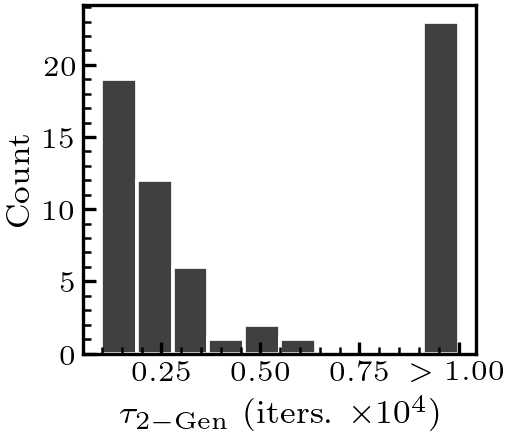

In [ ]:
fig, ax = plt.subplots(figsize=(1.75, 1.5), layout='constrained')
x = result["t_iha_threshold"].to_numpy() / 1e4
sns.histplot(x, bins=10, color='black', edgecolor='white', ax=ax)

ax.set_xlabel(r'$\tau_\mathrm{2-Gen}$ (iters. $\times 10^4$)')
ax.set_ylabel('Count')

fig.canvas.draw()

labels = [t.get_text() for t in ax.get_xticklabels()]
last = labels[-2].strip('$')      # remove surrounding math delimiters
labels[-2] = rf'$>{last}$'        # rebuild as proper mathtext

ax.set_xticklabels(labels)
plt.savefig(plot_dir / 'k1_bimodal_t.svg', bbox_inches = 'tight', dpi=300)

## Perturbations

In [ ]:
dirs = {
    'Control': Path("~/data/output/quick_crane_2"),
    'Task Injection (MLP2)': Path("~/data/output/critical_zebra"),
    'PTA Reweight (0.1)': Path("~/data/output/secure_hedgehog_1"),
}
model_perf = []
est_perf = []
order_params = []
for condition, dir in dirs.items():
    dir = dir.expanduser().resolve()
    data_dir = dir / "data"
    exp_config = u.load_config(dir / 'exp_config.yaml')
    print(exp_config.notes)
    n_seeds = len(exp_config.seedrange)
    n_n = len(exp_config.nrange)
    n_params = len(exp_config.paramrange)
    param_name = exp_config.param_name
    for seed in exp_config.seedrange:
        for n in exp_config.nrange:
            for param_value in exp_config.paramrange:
                try:
                    # model_perf.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_model_perf.csv').assign(lr=lr))
                    # est_perf.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_est_perf.csv').assign(lr=lr))
                    order_params.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_order_params.csv').assign(condition=condition))
                except FileNotFoundError:
                    continue
# model_perf = pd.concat(model_perf, ignore_index = True)
# est_perf = pd.concat(est_perf, ignore_index = True)
# merge = pd.merge(model_perf, est_perf, on = ['K', 'n', 'seed'], suffixes = ['_model', '_est'])
order_params = pd.concat(order_params, ignore_index = True)

see k1* at N = 2^8; update 3-26
task injection at MLP2 K1* bsearch; with RoPE; updated 3-26
pta grad reweighting 0.1; updated 3-27


In [ ]:
result = (
    order_params
    .groupby(["K", "seed", "n", "condition"])["iha_tot"]
    .max()
    .reset_index()
    .rename(columns={'iha_tot': 'max_iha_tot'})
)

k1 = (
    result[result['max_iha_tot'] > 0.45]
    .groupby(["seed", "n", "condition"])['K']
    .min()
    .reset_index()
    .rename(columns={'K': 'K1*'})
)
k1_task_injection = k1.copy()

/tmp/ipykernel_3505429/2525133955.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Control', 'LR', 'TI'], rotation = 0)


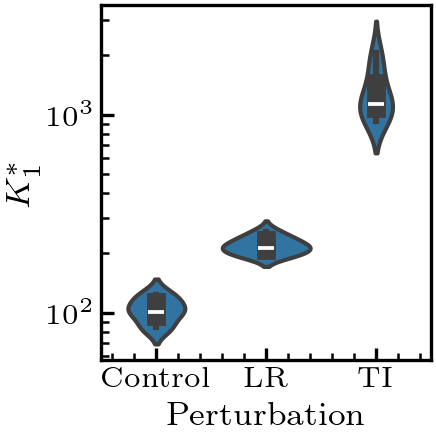

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (1.5, 1.5), layout = 'constrained')
mask = k1['condition'].isin(['Control', 'Task Injection (MLP2)', 'PTA Reweight (0.1)'])
sns.violinplot(k1[mask], x = 'condition', y = 'K1*', order = ['Control', 'PTA Reweight (0.1)',  'Task Injection (MLP2)'], log_scale=True, linewidth=1, ax=ax)
# sns.boxplot(k1[mask], x = 'condition', y = 'K1*', order = ['Control', 'PTA Reweight (0.1)',  'Task Injection (MLP2)'], ax=ax)
ax.set_ylabel(r'$K_1^*$')
ax.set_xlabel('Perturbation')
ax.set_xticklabels(['Control', 'LR', 'TI'], rotation = 0)
plt.savefig(plot_dir / 'k1_perturbations.svg', bbox_inches = 'tight')

# K2*

## reduced compilation

### loading

In [6]:
# uncomment for old data
# dir_list = [
#     # (Path("/mnt/shared/home/output/accepted_aardwolf"), ''),
#     # (Path("/mnt/shared/home/output/tricky_mongoose"), ''),
#     # (Path("/mnt/shared/home/output/consistent_ferret"), ''),
#     # (Path("/mnt/shared/home/output/nursing_goat"), ''), # fixed task seed
#     # (Path("/mnt/shared/home/output/depressed_boa"), ''),
#     # (Path("/mnt/shared/home/output/proposed_lobster"), ''),
#     # (Path("/mnt/shared/home/output/noble_dinosaur"), ''),
#     # (Path("/mnt/shared/home/output/sexual_mollusk"), ''),
#     # (Path("/mnt/shared/home/output/southern_echidna"), ''),
#     # (Path("/mnt/shared/home/output/particular_termite"), ''),
#     # (Path("/mnt/shared/home/output/confused_puma"), ''),
#     (OUTPUT_DIR / "fellow_wildfowl", ''),   # with weight decay
#     (OUTPUT_DIR / "judicial_trout", ''),
#     # (OUTPUT_DIR / "outstanding_penguin_0", ''),
#     # (OUTPUT_DIR / "outstanding_penguin_old", ''),
#     (OUTPUT_DIR / "outstanding_penguin_split_1", ''),
#     (OUTPUT_DIR / "outstanding_penguin_split_2", ''),
#     (OUTPUT_DIR / "outstanding_penguin_0", ''),
    # (OUTPUT_DIR / "outstanding_penguin_1", ''),
    # (OUTPUT_DIR / "outstanding_penguin_2", ''),
#     (OUTPUT_DIR / "outstanding_penguin_3", ''),
#     (OUTPUT_DIR / "outstanding_penguin_4", ''),
    # (OUTPUT_DIR / "outstanding_penguin_5", ''),
#     (OUTPUT_DIR / "outstanding_penguin_6", ''),
# ]

dir_list = [
    (OUTPUT_DIR / "loud-ermine", ''),
    (OUTPUT_DIR / "loud-ermine-2", ''),
    (OUTPUT_DIR / "weekly_crow", ''),
    (OUTPUT_DIR / "transience_K_5792" , ''),
    (OUTPUT_DIR / "transience_K_6000" , ''),
    (OUTPUT_DIR / "transience_K_5500" , ''),
    (OUTPUT_DIR / "transience_K_5250" , ''),
    (OUTPUT_DIR / "outstanding_penguin_1", ''),
    (OUTPUT_DIR / "outstanding_penguin_2", ''),
    (OUTPUT_DIR / "outstanding_penguin_5", ''),
    (OUTPUT_DIR / "outstanding_penguin_6", ''),
]

model_perf = []
est_perf = []
order_params = []
edge_ablation = []

fix_seeds={0,1,2,3}

for dir, label in dir_list:
    data_dir = dir / "data"
    exp_config = u.load_config(dir / 'exp_config.yaml')
    print(dir)
    print(exp_config.notes)
    print(exp_config.paramrange)
    print(exp_config.evaluate.seq_per_task)
    n_seeds = len(exp_config.seedrange)
    n_n = len(exp_config.nrange)
    n_params = len(exp_config.paramrange)
    param_name = exp_config.param_name
    for seed in exp_config.seedrange :
        if seed not in fix_seeds:
            continue
        for n in exp_config.nrange:
            for param_value in exp_config.paramrange:
                try:
                    model_perf.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_model_perf.csv'))
                    est_perf.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_est_perf.csv'))
                except FileNotFoundError:
                    continue
                try:
                    order_params.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_order_params.csv'))
                except FileNotFoundError:
                    pass
                # edge_ablation.append(pd.read_csv(data_dir /f'S{seed}_N{n}_{param_name}{param_value}_edge_causal.csv'))

model_perf = pd.concat(model_perf, ignore_index = True)
est_perf = pd.concat(est_perf, ignore_index = True)
order_params = pd.concat(order_params, ignore_index = True)
# edge_causal = pd.concat(edge_ablation, ignore_index = True)

# order_params["pta"] = order_params["pta"].apply(ast.literal_eval)
# order_params['logs'] = order_params['s'].apply(lambda x: math.log10(x))
# order_params["pta_vec"] = order_params['pta']
# order_params['pta'] = order_params['pta'].apply(lambda x: sum(x)/len(x))

for df in (model_perf, ):
    df['logK'] = df['K'].apply(lambda x: np.log2(x))
merge = pd.merge(model_perf, est_perf, on = ['K', 'n', 'seed'], suffixes = ['_model', '_est'])

/scratch/gpfs/GREDDY/cg5763/output/loud-ermine
4 seeds of long training for final transience results
[64, 90, 128, 256, 362, 512]
8
/scratch/gpfs/GREDDY/cg5763/output/loud-ermine-2
4 seeds of long training for final transience results
[181]
8
/scratch/gpfs/GREDDY/cg5763/output/weekly_crow
4 seeds of long training for final transience results
[724, 1024, 1448, 2048, 2896, 4096]
8
/scratch/gpfs/GREDDY/cg5763/output/transience_K_5792
4 seeds of long training for additional transience results
[5792]
8
/scratch/gpfs/GREDDY/cg5763/output/transience_K_6000
4 seeds of long training for additional transience results
[6000]
8
/scratch/gpfs/GREDDY/cg5763/output/transience_K_5500
4 seeds of long training for additional transience results
[5500]
8
/scratch/gpfs/GREDDY/cg5763/output/transience_K_5250
4 seeds of long training for additional transience results
[5250]
8
/scratch/gpfs/GREDDY/cg5763/output/outstanding_penguin_1
8 seeds for t_transience at very large K, fixed task seed, with weight decay


<Axes: xlabel='K', ylabel='iha_tot'>

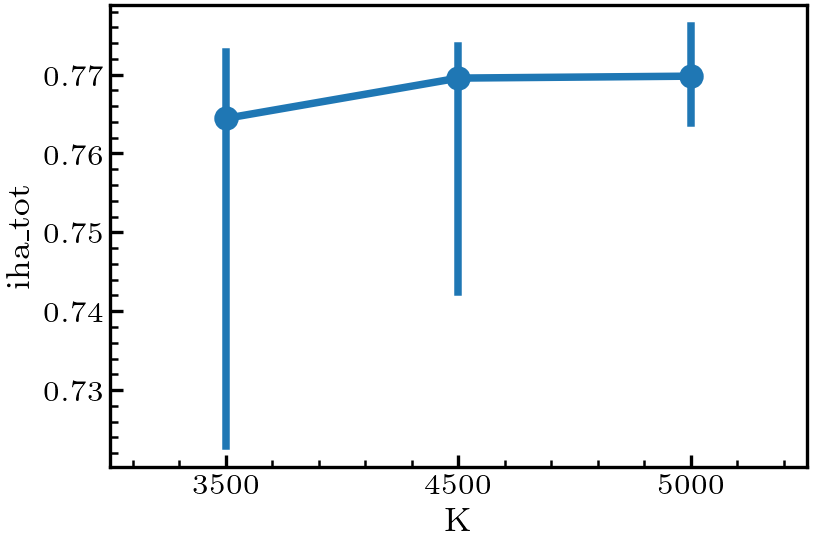

In [81]:
threshold = 799999

# Step 1: restrict to valid rows
subset = order_params[order_params['t'] <= threshold]

# Step 2: compute per-group max t
t_max = subset.groupby(['K', 'seed'])['t'].transform('max')

# Step 3: keep rows achieving that max
result = subset[subset['t'] == t_max]

sns.pointplot(result, x='K', y='iha_tot', estimator='median', errorbar='ci')

In [7]:
merge.groupby('K')['seed'].unique()

K
64      [0, 1, 2, 3]
90      [0, 1, 2, 3]
128     [0, 1, 2, 3]
181     [0, 1, 2, 3]
256     [0, 1, 2, 3]
362     [0, 1, 2, 3]
512     [0, 1, 2, 3]
724     [0, 1, 2, 3]
1024    [0, 1, 2, 3]
1448    [0, 1, 2, 3]
2048    [0, 1, 2, 3]
2896    [0, 1, 2, 3]
3500    [0, 2, 1, 3]
4096    [0, 1, 2, 3]
4500    [0, 1, 2, 3]
5000    [0, 1, 2, 3]
5250    [0, 1, 2, 3]
5500    [0, 1, 2, 3]
5792    [0, 1, 2, 3]
6000    [0, 1, 2, 3]
Name: seed, dtype: object

### loss

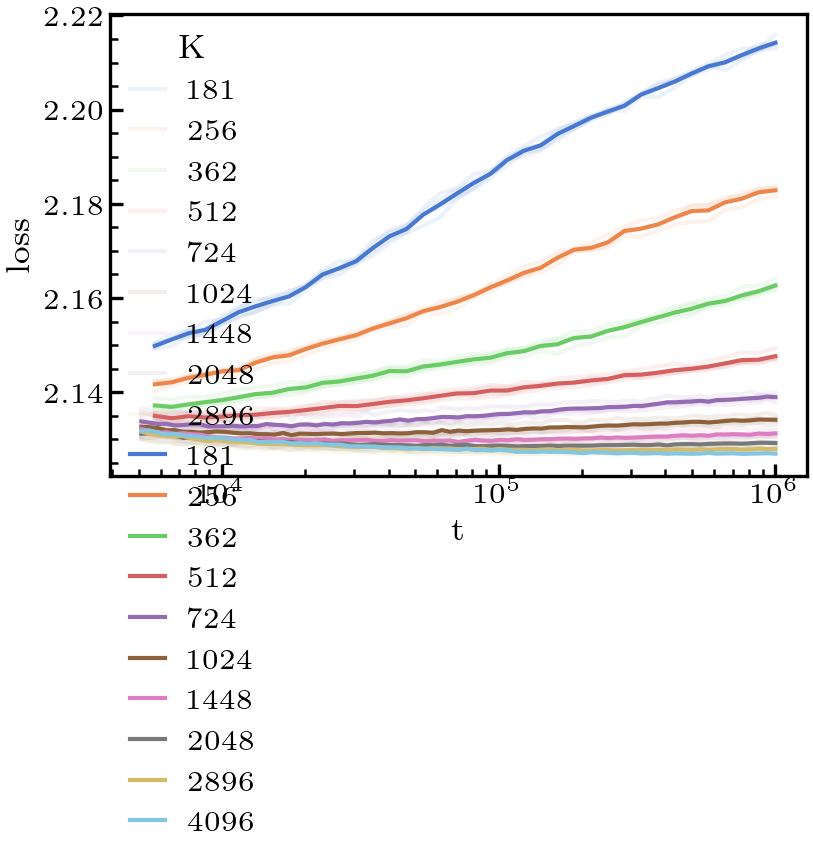

In [ ]:
ax = sns.lineplot(model_perf[model_perf['dist'].eq('val') & model_perf['K'].lt(3000) & model_perf['t'].gt(5e3)], x = 't', y = 'loss', hue = 'K', units='seed', estimator=None, palette = 'muted', alpha=0.1)
ax = sns.lineplot(model_perf[model_perf['dist'].eq('val') & model_perf['t'].gt(5e3)], x = 't', y = 'loss', hue = 'K', estimator='mean', errorbar=None, palette = 'muted', alpha=1)
ax.set_xscale('log', base=10)
# ax.set_ylim(top=2.18)

### t_transience

t_bigen

In [8]:
model_df = model_perf.copy()
run_keys = ['K', 'seed', 'n']
model_df = model_df.pivot_table(index=run_keys+['t'], columns='dist', values='loss')

t_bigen = (
    model_df
    .assign(mask=lambda df: df['val'] < 2.2)
    .reset_index()
    .loc[lambda df: df['mask']]
    .groupby(run_keys)['t']
    .min()
    .reset_index(name='t_bigen')
)

In [9]:
run_keys = ['K', 'seed', 'n']
est_df = est_perf.copy()

est_df = est_df[est_df['name'].eq('2_gen')]
est_df = est_df.pivot_table(index=run_keys, columns='dist', values='loss')

merge_df = pd.merge(model_df.reset_index(), est_df.reset_index(), on=run_keys, suffixes=('_model', '_est'))
mask = merge_df['train_model'].lt(merge_df['train_est'])

t_trans = (
    merge_df[mask]
    .groupby(run_keys)['t']
    .min()
    .reset_index()
    .rename(columns={'t': 't_trans'})
)

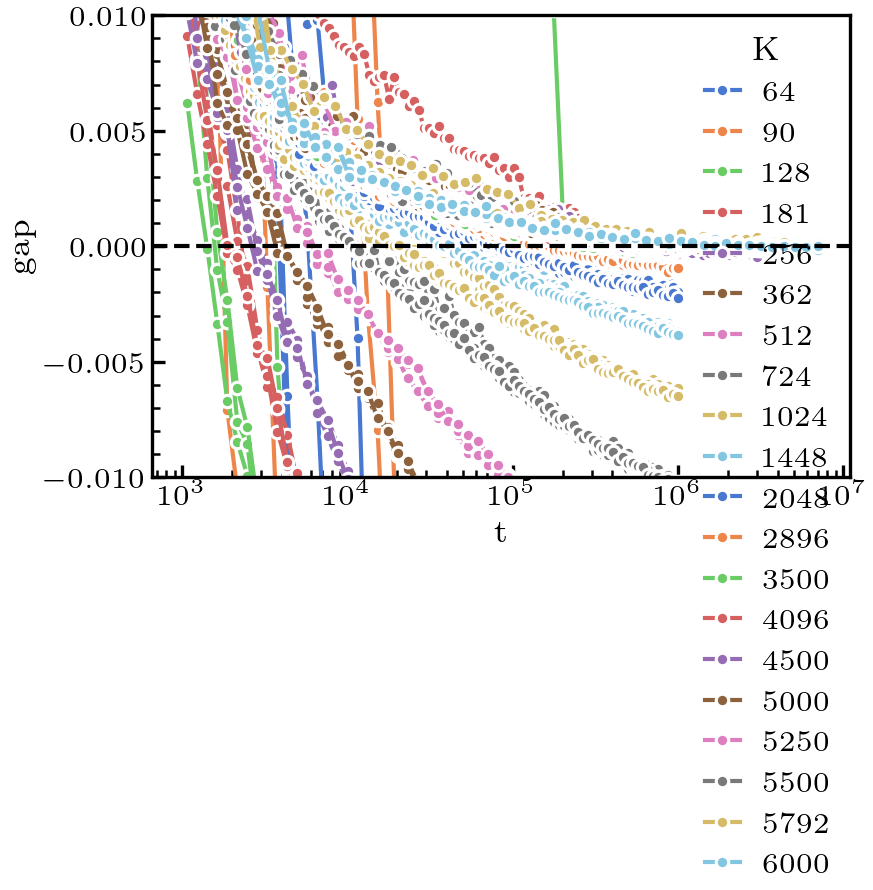

In [10]:
merge_df['gap'] = merge_df['train_model'] - merge_df['train_est']
ax = sns.lineplot(
    data=merge_df[merge_df['t'].gt(1e3)],
    x='t',
    y='gap',
    hue='K',
    units='seed',
    estimator=None,
    marker='o',
    palette='muted'
)
ax.set_xscale('log')
ax.set_ylim(top=1e-2, bottom=-1e-2)
ax.axhline(0, color='black', linestyle='--')

In [11]:
import numpy as np
import pandas as pd

run_keys = ['K', 'seed', 'n']

model_df = model_perf.copy()
model_df = model_df.pivot_table(index=run_keys + ['t'], columns='dist', values='loss')

est_df = est_perf.copy()
est_df = est_df[est_df['name'].eq('2_gen')]
est_df = est_df.pivot_table(index=run_keys, columns='dist', values='loss')

merge_df = pd.merge(
    model_df.reset_index(),
    est_df.reset_index(),
    on=run_keys,
    suffixes=('_model', '_est')
).copy()

# y(t) = train_model(t) - train_est
merge_df['y'] = merge_df['train_model'] - merge_df['train_est']

# sort within runs
df = merge_df.sort_values(run_keys + ['t']).copy()

# previous point within run
df['t_prev'] = df.groupby(run_keys)['t'].shift(1)
df['y_prev'] = df.groupby(run_keys)['y'].shift(1)

# require positive times for log interpolation
valid_time = df['t_prev'].gt(0) & df['t'].gt(0)

# downward crossing: y_prev >= 0 and y < 0
# cross = valid_time & df['y_prev'].ge(0) & df['y'].lt(-1e-4)
cross = valid_time & df['y_prev'].ge(0) & df['y'].lt(0)

# log-time coordinates
df['log_t'] = np.log(df['t'])
df['log_t_prev'] = np.log(df['t_prev'])

# interpolate linearly in log t space:
# y = y_prev + (log_t_cross - log_t_prev) * (y - y_prev)/(log_t - log_t_prev)
# solve for log_t_cross, then exponentiate
df.loc[cross, 'log_t_cross'] = (
    df.loc[cross, 'log_t_prev']
    + (0.0 - df.loc[cross, 'y_prev'])
      * (df.loc[cross, 'log_t'] - df.loc[cross, 'log_t_prev'])
      / (df.loc[cross, 'y'] - df.loc[cross, 'y_prev'])
)

df.loc[cross, 't_cross'] = np.exp(df.loc[cross, 'log_t_cross'])

t_trans = (
    df.loc[cross]
      .groupby(run_keys, as_index=False)['t_cross']
      .min()
      .rename(columns={'t_cross': 't_trans'})
)

2.6281368869358186


Text(0.5, 0, '$K$')

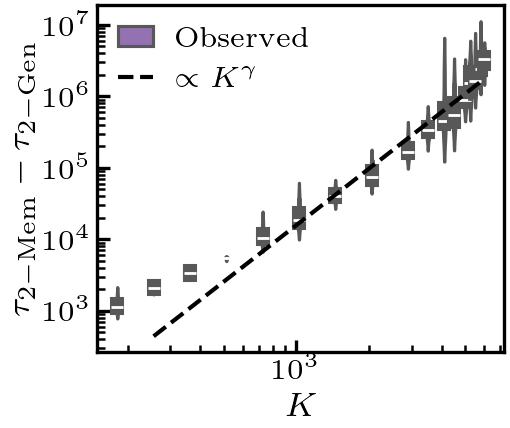

In [12]:
fig, ax = plt.subplots(figsize=(1.75, 1.5))

# subtract t_bigen from t_transience
merged = pd.merge(t_trans, t_bigen, on=run_keys)
merged['t_persistent'] = merged['t_trans'] - merged['t_bigen']

N = 8 # number of seeds per run_key

# reasonable K range with interpretable dynamics
df_filtered = (
    merged[merged['K'].gt(2**7)]
    .sort_values('seed')
    .groupby(['K', 'n'], group_keys=False)
    .head(N)
)

df_fit = (
    df_filtered[df_filtered['K'].gt(2**9)]
    .groupby(['K', 'n'])['t_persistent']
    .median()
    .reset_index()
)

x = df_fit['K'].values
y = df_fit['t_persistent'].values

mask = (x > 0) & (y > 0)
x, y = x[mask], y[mask]

logx = np.log(x)
logy = np.log(y)

b, loga = np.polyfit(logx, logy, 1)
a = np.exp(loga)

# x_fit = np.linspace(x.min(), x.max(), 200)
x_fit = np.linspace(2**8, x.max(), 200)
y_fit = a * x_fit**b

print(b)

sns.violinplot(df_filtered, x='K', y='t_persistent',
                    native_scale=True,
                    color='C4',
                    log_scale=True,
                    ax=ax,
                    linewidth=0.75,
                    density_norm='width',
                    label='Observed',
)

# sns.boxplot(df_filtered, x='K', y='t_persistent',
#                     native_scale=True,
#                     color='C4',
#                     log_scale=True,
#                     ax=ax,
#                     linewidth=1,
#                     label='Observed',
#                     flierprops=dict(markersize=3),
# )

ax.plot(
    x_fit,
    y_fit, 
    color='black', 
    linestyle='--',
    linewidth=1,
    label=r'$\propto K^{\gamma}$',
    )

# only include first two legend entries
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], labels[-2:])

ax.set_ylabel(r'$\tau_{\mathrm{2-Mem}} - \tau_{\mathrm{2-Gen}}$')
ax.set_xlabel(r'$K$')

# ax.plot(2**13, 6e6, marker='x', color='red', label='')

# ax.axvline(5e3, color='black', linestyle=':', linewidth=1)

# plt.savefig(plot_dir / 'trans_dynamics.svg')

In [13]:
print('check that all seeds have converged sufficiently')
df_filtered.groupby('K')['seed'].unique()

check that all seeds have converged sufficiently


K
181     [0, 1, 2, 3]
256     [0, 1, 2, 3]
362     [0, 1, 2, 3]
512     [0, 1, 2, 3]
724     [0, 1, 2, 3]
1024    [0, 1, 2, 3]
1448    [0, 1, 2, 3]
2048    [0, 1, 2, 3]
2896    [0, 1, 2, 3]
3500    [0, 1, 2, 3]
4096    [0, 1, 2, 3]
4500    [0, 1, 2, 3]
5000    [0, 1, 2, 3]
5250    [0, 1, 2, 3]
5500    [0, 1, 2, 3]
5792    [0, 1, 2, 3]
6000    [0, 1, 2, 3]
Name: seed, dtype: object

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def fit_divergence(
    x,
    y,
    ax,
    *,
    sigma=None,
    eps_frac=1e-12,
    ngrid=600,
    p0=None,
    label_data="data",
    label_fit="divergence fit",
    # --- divergence options ---
    div_form="shifted",   # "simple" : y = A * (x0 - x)^(-b)
                          # "shifted": y = y_inf + A * (x0 - x)^(-b)
    p0_div=None,
    # --- exponential options ---
    do_exp_fit=True,
    exp_form="shifted",   # "simple" : y = C * exp(k x)
                          # "shifted": y = y_inf + C * exp(k x)
    p0_exp=None,
    label_exp="exp fit",
    # --- NEW: plotting-domain options ---
    plot_extend=(0.0, 0.0),   # (left_frac, right_frac) of data span
    plot_xlim=None,           # (xmin_plot, xmax_plot) absolute; overrides plot_extend
    plot_clip_to_x0=True,     # avoid plotting past the fitted singularity x0
    x0_margin_frac=1e-6,      # margin relative to max(1, span) when clipping to x0
):
    """
    Divergence forms:
      - "simple" : y = A * (x0 - x)^(-b), with A>0, b>0, x0>max(x)
      - "shifted": y = y_inf + A * (x0 - x)^(-b), with A>0, b>0, x0>max(x), y_inf free

    Exponential forms:
      - "simple" : y = C * exp(k x), with C>0
      - "shifted": y = y_inf + C * exp(k x), with C>0, y_inf free
    """
    x = np.asarray(x, float).ravel()
    y = np.asarray(y, float).ravel()
    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape")

    m = np.isfinite(x) & np.isfinite(y)

    if sigma is not None:
        sigma = np.asarray(sigma, float).ravel()
        if sigma.shape != y.shape:
            raise ValueError("sigma must have same shape as y")
        m &= np.isfinite(sigma) & (sigma > 0)
        sigma_fit = sigma[m]
    else:
        sigma_fit = None

    x_d = x[m]
    y_d = y[m]
    if x_d.size < 3:
        raise ValueError("Need at least 3 valid points")

    xmin, xmax = x_d.min(), x_d.max()
    xspan = xmax - xmin
    eps = eps_frac * max(xspan, 1.0)

    # ---- divergence model ----
    if div_form == "simple":
        def model_div(xv, A, x0, b):
            return A * (x0 - xv + eps) ** (-b)

        if p0_div is None:
            A0 = max(np.max(y_d), 1e-12)
            x0_0 = xmax + 0.2 * max(xspan, 1.0)
            b0 = 1.0
            p0_div = (A0, x0_0, b0)

        bounds_div = (
            (0.0, xmax + 1e-12, 0.0),
            (np.inf, np.inf, np.inf),
        )

    elif div_form == "shifted":
        def model_div(xv, y_inf, A, x0, b):
            return y_inf + A * (x0 - xv + eps) ** (-b)

        if p0_div is None:
            yinf0 = np.min(y_d)
            A0 = max(np.max(y_d) - yinf0, 1e-12)
            x0_0 = xmax + 0.2 * max(xspan, 1.0)
            b0 = 1.0
            p0_div = (yinf0, A0, x0_0, b0)

        bounds_div = (
            (-np.inf, 0.0, xmax + 1e-12, 0.0),
            ( np.inf, np.inf, np.inf, np.inf),
        )
    else:
        raise ValueError("div_form must be 'simple' or 'shifted'")

    popt_div, pcov_div = curve_fit(
        model_div,
        x_d,
        y_d,
        p0=p0_div if p0 is None else p0,
        bounds=bounds_div,
        sigma=sigma_fit,
        absolute_sigma=(sigma_fit is not None),
        maxfev=20000,
    )

    # ---- plotting data ----
    # ax.scatter(x_d, y_d, s=3, label=label_data)
    # sns.pointplot(x=x_d, y=y_d, color='C0', ax=ax, markersize=1, estimator='median', errorbar='ci', label=label_data, native_scale=True, linewidth=1)

    # ---- NEW: choose plotting domain ----
    if plot_xlim is not None:
        xmin_plot, xmax_plot = map(float, plot_xlim)
        if not (np.isfinite(xmin_plot) and np.isfinite(xmax_plot) and xmin_plot < xmax_plot):
            raise ValueError("plot_xlim must be (xmin_plot, xmax_plot) with xmin_plot < xmax_plot")
    else:
        left_frac, right_frac = plot_extend
        if not (np.isfinite(left_frac) and np.isfinite(right_frac)):
            raise ValueError("plot_extend must be (left_frac, right_frac) finite numbers")
        span = max(xspan, 1.0)
        xmin_plot = xmin - left_frac * span
        xmax_plot = xmax + right_frac * span

    # Clip curve to remain left of the fitted x0 (avoid crossing the singularity)
    if plot_clip_to_x0:
        if div_form == "simple":
            _, x0_hat, _ = popt_div
        else:
            _, _, x0_hat, _ = popt_div
        margin = x0_margin_frac * max(xspan, 1.0)
        xmax_plot = min(xmax_plot, x0_hat - margin)

    xx = np.linspace(xmin_plot, xmax_plot, ngrid)
    yy_div = model_div(xx, *popt_div)

    if div_form == "simple":
        A_hat, x0_hat, b_hat = popt_div
        div_label = (
            rf"{label_fit}: $A(x_0-x)^{{-b}}$, "
            rf"$x_0={x0_hat:.6g}$, $b={b_hat:.3g}$"
        )
    else:
        yinf_hat, A_hat, x0_hat, b_hat = popt_div
        div_label = (
            rf"{label_fit}: $y_\infty + A(x_0-x)^{{-b}}$, "
            rf"$y_\infty={yinf_hat:.6g}$, $x_0={x0_hat:.6g}$, $b={b_hat:.3g}$"
        )

    ax.plot(xx, yy_div, linewidth=1, label=div_label, color='black', linestyle='--')

    # ---- optional exponential fit ----
    popt_exp, pcov_exp = None, None
    if do_exp_fit:
        if exp_form == "simple":
            def model_exp(xv, C, k):
                return C * np.exp(k * xv)

            if p0_exp is None:
                y_pos = y_d[y_d > 0]
                C0 = np.median(y_pos) if y_pos.size >= 2 else max(np.median(y_d), 1e-12)
                k0 = 0.0
                p0_exp = (C0, k0)

            bounds_exp = ((0.0, -np.inf), (np.inf, np.inf))

        elif exp_form == "shifted":
            def model_exp(xv, y_inf, C, k):
                return y_inf + C * np.exp(k * xv)

            if p0_exp is None:
                y_inf0 = np.min(y_d)
                C0 = max(np.max(y_d) - y_inf0, 1e-12)
                k0 = 0.0
                p0_exp = (y_inf0, C0, k0)

            bounds_exp = ((-np.inf, 0.0, -np.inf), (np.inf, np.inf, np.inf))
        else:
            raise ValueError("exp_form must be 'simple' or 'shifted'")

        popt_exp, pcov_exp = curve_fit(
            model_exp,
            x_d,
            y_d,
            p0=p0_exp,
            bounds=bounds_exp,
            sigma=sigma_fit,
            absolute_sigma=(sigma_fit is not None),
            maxfev=20000,
        )

        yy_exp = model_exp(xx, *popt_exp)

        if exp_form == "simple":
            C_hat, k_hat = popt_exp
            exp_label = rf"{label_exp}: $C e^{{kx}}$, $k={k_hat:.3g}$"
        else:
            yinf_hat, C_hat, k_hat = popt_exp
            exp_label = (
                rf"{label_exp}: $y_\infty + C e^{{kx}}$, "
                rf"$y_\infty={yinf_hat:.6g}$, $k={k_hat:.3g}$"
            )

        ax.plot(xx, yy_exp, linewidth=1, linestyle="--", label=exp_label)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

    return (popt_div, pcov_div), (popt_exp, pcov_exp)

Text(0, 0.5, '$\\tau_\\mathrm{2-Mem} - \\tau_\\mathrm{2-Gen}$')

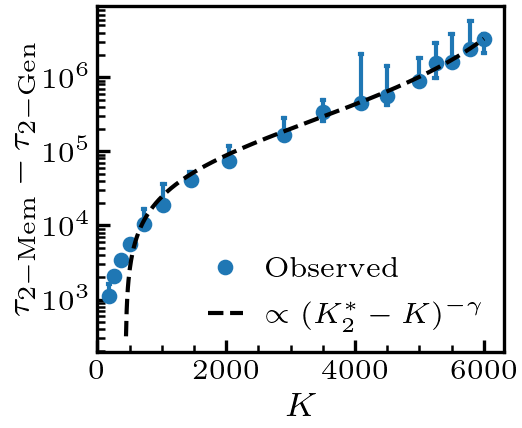

In [15]:
fig, ax = plt.subplots(figsize=(1.75, 1.5))

# compute median of t_persistent over seeds for each (K, n)
t_persistent = (
    merged
    .groupby(['K', 'n'])['t_persistent']
    .median()
    .reset_index()
)

x = np.asarray(t_persistent['K'])
y = np.asarray(t_persistent['t_persistent'])

sns.pointplot(
    data=df_filtered,
    x='K',
    y='t_persistent',
    color='C0', 
    ax=ax, markersize=3, 
    estimator='median', 
    errorbar='ci', 
    native_scale=True, 
    linewidth=1, 
    capsize=0.5, 
    linestyle='none', 
    label='Observed',
    log_scale = (False, True)
    )

(div_popt, div_pcov), (exp_popt, exp_pcov) = fit_divergence(
    x, y, ax,
    do_exp_fit=False,
    div_form="shifted",
    plot_extend=(0.0, 0.0),  # extend 10% of data range on both sides for better visualization
)

ax.set_xlim(left=0)
ax.set_xlabel(r'$K$')
ax.set_ylabel(r'$\tau_\mathrm{transience}$')

handles, labels = ax.get_legend_handles_labels()
labels = [
    'Observed', 
    rf'$\propto (K_2^* - K)^{{-\gamma}}$',
    ]

ax.legend(handles, labels)

ax.set_ylabel(r'$\tau_\mathrm{2-Mem} - \tau_\mathrm{2-Gen}$')

2.035376915491571
fit to last 8 unique values


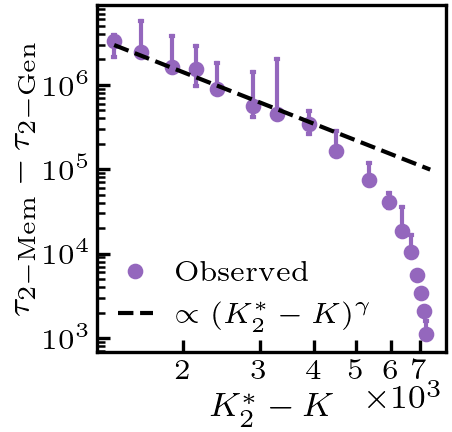

In [23]:
import matplotlib.ticker as mticker

K2_star = div_popt[-2]
gamma = div_popt[-1]

fig, ax = plt.subplots(figsize=(1.5, 1.5))

df_filtered['K_diff_K2'] = K2_star - df_filtered['K']

sns.pointplot(df_filtered, x='K_diff_K2', y='t_persistent',
                    color='C4',
                    log_scale=True,
                    ax=ax,
                    linestyle='none',
                    markersize=3,
                    linewidth = 1,
                    capsize=1,
                    estimator='median',
                    errorbar='ci',
                    native_scale=True,
                    label='Observed',
)

# plot linear fit at large K
df_fit = (
    df_filtered[df_filtered['K'].gt(3000)]
    .groupby(['K_diff_K2', 'n'])['t_persistent']
    .median()
    .reset_index()
)

x = df_fit['K_diff_K2'].values
y = df_fit['t_persistent'].values

mask = (x > 0) & (y > 0)
x, y = x[mask], y[mask]

logx = np.log(x)
logy = np.log(y)

loga = np.mean(logy + gamma * logx)
b = gamma

# b, loga = np.polyfit(logx, logy, 1)
a = np.exp(loga)

# x_fit = np.linspace(x.min(), x.max(), 200)
x_fit = np.linspace(x.min(), K2_star, 200)
y_fit = a * x_fit**-b

print(b)

sns.lineplot(
    x=x_fit,
    y=y_fit, 
    color='black', 
    linestyle='--',
    linewidth=1,
    label=r'$\propto (K_2^* - K)^{\gamma}$',
)

# only include first two legend entries
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[-2:], labels[-2:])

ax.set_ylabel(r'$\tau_{\mathrm{2-Mem}} - \tau_{\mathrm{2-Gen}}$')
ax.set_xlabel(r'$K_2^\ast - K$')

ticks = [2e3, 3e3, 4e3, 5e3, 6e3, 7e3]
ax.set_xticks(ticks)
ax.set_xticklabels([r"$2$", r"$3$", r"$4$", r"$5$", r"$6$", r"$7$"])
ax.xaxis.set_minor_locator(mticker.NullLocator())

ax.text(
    1.0, -0.08,                 # right end, slightly below axis
    r"$\times 10^3$",
    transform=ax.transAxes,
    ha="right",                  # sit just to the right of last tick
    va="top"
)

ax.set_xlabel(r"$K_2^\ast - K$")
# ax.set_aspect('equal')
print(f'fit to last {df_fit["K_diff_K2"].nunique()} unique values')

2.035376915491571
fit to last 8 unique values


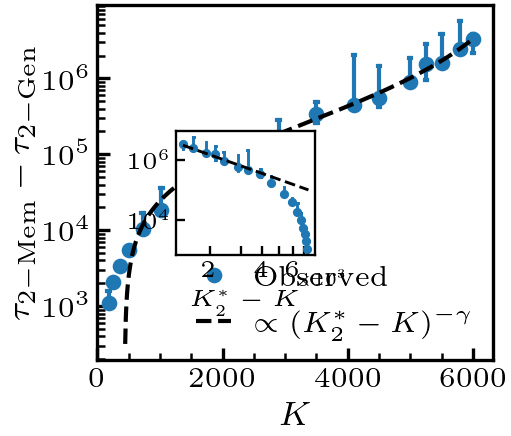

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

t_persistent = (
    merged
    .groupby(['K', 'n'])['t_persistent']
    .median()
    .reset_index()
)

x = np.asarray(t_persistent['K'])
y = np.asarray(t_persistent['t_persistent'])

# --- main figure / main axis ---
fig, ax = plt.subplots(figsize=(1.75, 1.5), layout='constrained')

sns.pointplot(
    data=df_filtered,
    x='K',
    y='t_persistent',
    color='C0',
    ax=ax,
    markersize=3,
    estimator='median',
    errorbar='ci',
    native_scale=True,
    linewidth=1,
    capsize=0.5,
    linestyle='none',
    label='Observed',
    log_scale=(False, True)
)

(div_popt, div_pcov), (exp_popt, exp_pcov) = fit_divergence(
    x, y, ax,
    do_exp_fit=False,
    exp_form="shifted",
    plot_extend=(0.0, 0.0),
)

ax.set_xlim(left=0)
ax.set_xlabel(r'$K$')
ax.set_ylabel(r'$\tau_\mathrm{2-Mem} - \tau_\mathrm{2-Gen}$')

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [
        'Observed',
        rf'$\propto (K_2^* - K)^{{-\gamma}}$',
    ],
    frameon=False,
    loc = 'lower right',
    fontsize=7
)

# --- inset axis ---
axins = inset_axes(
    ax,
    width="35%",
    height="35%",
    bbox_to_anchor=(0.2, -0.03, 1, 1),
    bbox_transform=ax.transAxes,
    loc="center left",
    borderpad=0,
)

inset_scale = 0.7

K2_star = div_popt[2]
gamma = div_popt[3]

# avoid mutating the original dataframe unless you actually want that column globally
df_inset = df_filtered.copy()
df_inset['K_diff_K2'] = K2_star - df_inset['K']

sns.pointplot(
    data=df_inset,
    x='K_diff_K2',
    y='t_persistent',
    color='C0',
    log_scale=True,
    ax=axins,
    linestyle='none',
    markersize=3*inset_scale*0.8,
    linewidth=1*inset_scale,
    capsize=1*inset_scale,
    estimator='median',
    errorbar='ci',
    native_scale=True,
    label='Observed',
)

# fit using large-K data
df_fit = (
    df_inset[df_inset['K'].gt(3000)]
    .groupby(['K_diff_K2', 'n'])['t_persistent']
    .median()
    .reset_index()
)

x_fit_data = df_fit['K_diff_K2'].values
y_fit_data = df_fit['t_persistent'].values

# mask = (x_fit_data > 0) & (y_fit_data > 0)
# x_fit_data = x_fit_data[mask]
# y_fit_data = y_fit_data[mask]

logx = np.log(x_fit_data)
logy = np.log(y_fit_data)

loga = np.mean(logy + gamma * logx)
b = gamma
a = np.exp(loga)

x_fit_line = np.linspace(x_fit_data.min(), K2_star, 200)
y_fit_line = a * x_fit_line**(-b)

sns.lineplot(
    x=x_fit_line,
    y=y_fit_line,
    color='black',
    linestyle='--',
    linewidth=1*inset_scale,
    ax=axins,
    label=rf'$\propto (K_2^* - K)^{{-\gamma}}$',
)

# inset formatting
axins.set_xscale('log')
axins.set_yscale('log')

axins.set_ylabel('')
axins.set_xlabel(r'$K_2^\ast - K$', fontsize=plt.rcParams['font.size']*inset_scale)

ticks = [2e3, 3e3, 4e3, 5e3, 6e3, 7e3]
axins.set_xticks(ticks)
axins.set_xticklabels([r"$2$", "", r"$4$", "", r"$6$", ""], fontsize=plt.rcParams['font.size']*inset_scale)
axins.xaxis.set_minor_locator(mticker.NullLocator())

axins.text(
    1.25, -0.1,
    r"$\times 10^3$",
    transform=axins.transAxes,
    ha="right",
    va="top",
    fontsize=6*inset_scale,
)

axins.tick_params(axis='both', which='major', labelsize=8*inset_scale, length=plt.rcParams['xtick.major.size']*inset_scale, width=plt.rcParams['xtick.major.width']*inset_scale, pad=plt.rcParams['xtick.major.pad']*inset_scale)
axins.tick_params(axis='both', which='minor', labelsize=8*inset_scale, length=plt.rcParams['xtick.minor.size']*inset_scale, width=plt.rcParams['xtick.minor.width']*inset_scale, pad=plt.rcParams['xtick.minor.pad']*inset_scale)

for spine in axins.spines.values():
    spine.set_linewidth(plt.rcParams['axes.linewidth']*inset_scale)

# # keep only inset's two legend entries
# handles_ins, labels_ins = axins.get_legend_handles_labels()
# axins.legend(handles_ins[-2:], labels_ins[-2:], fontsize=7, frameon=False)
axins.legend().remove()  # remove inset legend since main axis already has the same entries

print(b)
print(f'fit to last {df_fit["K_diff_K2"].nunique()} unique values')

plt.savefig(plot_dir / 'transience_divergence.svg', bbox_inches='tight')

## partial memorization

In [ ]:
results_dir = Path('/home/cg5763/data/analysis/per_task_eval')

# read every csv in results_dir and concatenate into a single DataFrame
# all_files = list(results_dir.glob('*1024.csv')) + list(results_dir.glob('*256.csv')) + list(results_dir.glob('*512.csv')) + ['/mnt/shared/home/icl/pd/analysis/partial_mem_data/per_task_eval_seed_0.csv']
# all_files = [file for K in np.logspace(7, 11, base=2, num=9, dtype=int).tolist() for file in results_dir.glob(f'*{K}.csv')]
# all_files = list(results_dir.glob('*.csv'))
all_files = list(results_dir.glob('*inf.csv'))
df_list = []
for file in all_files:
    try:
        df = pd.read_csv(file)
    except UnicodeDecodeError:
        print(f"Could not read {file}, skipping.")
        continue
    df_list.append(df)

result = pd.concat(df_list, ignore_index=True)

In [7]:
# compute gap
# result = result[~result['seed'].isin([4, 6])]
result['gap'] = result['model_loss'] - result['est_loss']

# compute per task means of the gap
task_gap = result.groupby(['task', 'K', 'seed', 't'])['gap'].mean().reset_index()

# number of negative gap tasks over time
threshold = -1e-3
task_gap['negative'] = task_gap['gap'] < threshold
neg_counts = task_gap.groupby(['K', 'seed', 't'])['negative'].sum().reset_index()
neg_counts['fraction'] = neg_counts['negative'] / task_gap.groupby(['K', 'seed', 't'])['task'].nunique().values

In [9]:
result[result['t'].eq(999999)].groupby(['K', 'seed'])['model_loss'].count()

K    seed
inf  0       647168
     2       647168
     3       647168
Name: model_loss, dtype: int64

In [10]:
neg_counts.groupby(['K', 'seed'])['t'].max()

K    seed
inf  0       999999
     2       999999
     3       999999
Name: t, dtype: int64

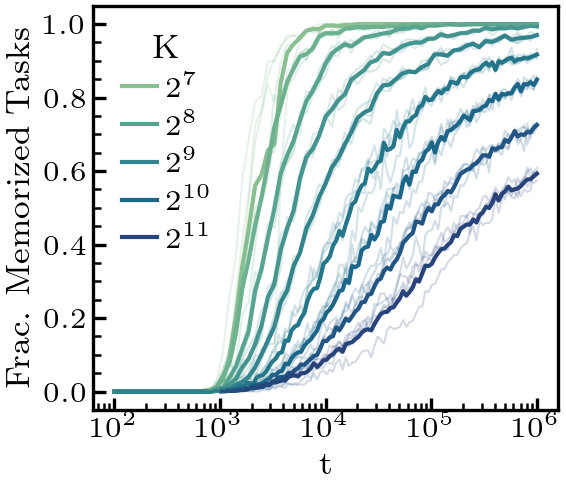

In [60]:
# data = neg_counts[(neg_counts['K'] % 500 == 0) | neg_counts['K'].isin([256])]
data = neg_counts.copy()
fig, ax = plt.subplots(figsize=(2, 1.75))

unique_K = sorted(data['K'].unique())
palette = sns.color_palette('crest', n_colors=len(unique_K))

sns.lineplot(data, x='t', y='fraction', hue='K', estimator='mean', palette=palette, alpha=1.0, errorbar=None, linewidth=1, ax=ax)
sns.lineplot(data, x='t', y='fraction', hue='K', units='seed', estimator=None, palette=palette, alpha=0.2, legend=False, linewidth=0.5, ax=ax)

ax.set_xscale('log')
ax.set_xlabel('t')
ax.set_ylabel('Frac. Memorized Tasks')

handles, labels = ax.get_legend_handles_labels()
new_labels = [rf'$2^{{{np.log2(int(label)).astype(int)}}}$' for label in labels]
# new_labels = [str(2**num) for num in nums]
ax.legend(handles[::2], new_labels[::2], title='K', loc='upper left',
    # fontsize=6,
    labelspacing=0.4,
    handletextpad=0.3,
    borderpad=0.5,
    # title_fontsize=6,
    columnspacing=0.5,
    ncol=1)

plt.savefig(plot_dir / 'afig_mem_fraction_dynamics.svg')

       K  seed     A_fit        tau_fit      n_fit
0    128     0  0.995645    3737.520015  11.943470
1    128     1  0.993507    1597.178328   4.413860
2    128     2  0.993796    1815.342781   4.750769
3    128     3  0.993381    1930.590428   4.711772
4    181     0  0.991805    2522.650228   3.437603
5    181     1  0.992347    2298.515496   3.014503
6    181     2  0.996911    2349.378555   2.774955
7    181     3  0.993981    2363.519617   2.863034
8    256     0  0.988103    3430.762274   2.460581
9    256     1  0.986554    3471.047865   2.343004
10   256     2  0.987952    3338.571379   2.354173
11   256     3  0.990022    3547.791847   2.249260
12   362     0  0.962347    5159.394146   1.921348
13   362     1  0.966448    5106.109928   1.930466
14   362     2  0.967745    4975.823695   1.789539
15   362     3  0.968004    5258.421801   1.862849
16   512     0  0.940533    7946.183632   1.501179
17   512     1  0.940089    8135.167197   1.620758
18   512     2  0.935130    773

/tmp/ipykernel_378969/1601504113.py:135: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(fit_group_weighted, tail_weight=None)


Text(0, 0.5, 'Capacity (frac. $\\mathcal{D}_T$)')

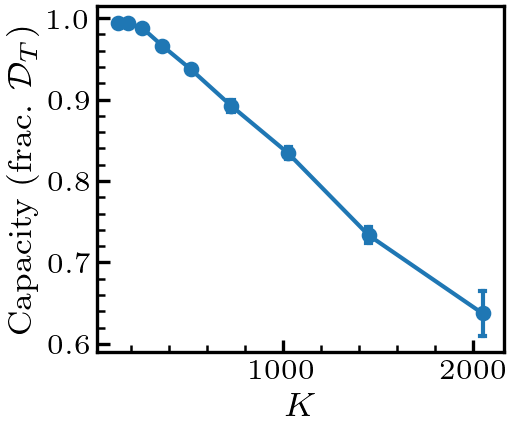

In [12]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit


def hill_sat(t, A, tau, n):
    """
    Hill-type saturation curve with known baseline y(0)=0 and asymptote A <= 1.

    Parameters
    ----------
    t : array-like
        Nonnegative times.
    A : float
        Saturation value, constrained to [0, 1].
    tau : float
        Half-saturation timescale (> 0).
    n : float
        Hill coefficient (> 0).

    Returns
    -------
    ndarray
        Model values.
    """
    t = np.asarray(t, dtype=float)
    t_pow = np.power(t, n)
    tau_pow = tau ** n
    return A * t_pow / (t_pow + tau_pow)


def fit_group_weighted(
    df,
    tail_weight="logt",
    min_points=3,
    min_positive_t=2,
    maxfev=20000,
):
    """
    Fit a Hill saturation curve with:
      - known starting value y(0)=0
      - constrained saturation 0 <= A <= 1

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain columns 't' and 'fraction'.
    tail_weight : {'logt', 't', None}, default 'logt'
        Weighting scheme to emphasize larger t.
    min_points : int, default 3
        Minimum number of finite points required.
    min_positive_t : int, default 2
        Minimum number of strictly positive t values required.
    maxfev : int, default 20000
        Maximum function evaluations for curve_fit.

    Returns
    -------
    pandas.Series
        Keys: A_fit, tau_fit, n_fit
    """
    g = df.sort_values("t").copy()
    t = g["t"].to_numpy(dtype=float)
    y = g["fraction"].to_numpy(dtype=float)

    mask = np.isfinite(t) & np.isfinite(y)
    t = t[mask]
    y = y[mask]

    if len(t) < min_points or np.sum(t > 0) < min_positive_t:
        return pd.Series({"A_fit": np.nan, "tau_fit": np.nan, "n_fit": np.nan})

    # The model is intended for nonnegative t and fractions in [0, 1].
    valid = (t >= 0) & (y >= 0) & (y <= 1)
    t = t[valid]
    y = y[valid]

    if len(t) < min_points or np.sum(t > 0) < min_positive_t:
        return pd.Series({"A_fit": np.nan, "tau_fit": np.nan, "n_fit": np.nan})

    t_pos = t[t > 0]

    # Initialization:
    # A0 should respect the known upper bound.
    A0 = float(np.clip(np.nanmax(y), 1e-6, 0.999))
    tau0 = float(np.median(t_pos))
    n0 = 2.0

    # Larger weight => smaller sigma in curve_fit
    if tail_weight == "logt":
        w = np.ones_like(t, dtype=float)
        pos = t > 0
        if np.any(pos):
            lt = np.log(t[pos])
            span = lt.max() - lt.min()
            if span > 0:
                lt_scaled = (lt - lt.min()) / span
            else:
                lt_scaled = np.zeros_like(lt)
            w[pos] = 1.0 + 4.0 * lt_scaled
    elif tail_weight == "t":
        w = np.ones_like(t, dtype=float)
        tmax = np.max(t)
        if tmax > 0:
            w = 1.0 + 4.0 * (t / tmax)
    else:
        w = np.ones_like(t, dtype=float)

    sigma = 1.0 / w

    try:
        popt, _ = curve_fit(
            hill_sat,
            t,
            y,
            p0=[A0, tau0, n0],
            bounds=([0.0, 1e-12, 1e-12], [1.0, np.inf, np.inf]),
            sigma=sigma,
            absolute_sigma=False,
            maxfev=maxfev,
        )
        A_fit, tau_fit, n_fit = popt
    except (RuntimeError, ValueError):
        A_fit, tau_fit, n_fit = np.nan, np.nan, np.nan

    return pd.Series({
        "A_fit": A_fit,
        "tau_fit": tau_fit,
        "n_fit": n_fit,
    })

fits = (
    neg_counts
    .groupby(["K", "seed"], group_keys=False)
    .apply(fit_group_weighted, tail_weight=None)
    .reset_index()
)

print(fits)

fig, ax = plt.subplots(figsize=(1.75, 1.5))
sns.pointplot(
    fits,
    x='K', 
    y='A_fit', 
    ax=ax, 
    estimator='mean', 
    errorbar='sd', 
    markersize=3, 
    capsize=0.5,
    linewidth=1, 
    # log_scale=(True, False), 
    native_scale=True
    )

ax.set_xlabel(r'$K$')
ax.set_ylabel(r'Capacity (frac. $\mathcal{D}_T$)')

# plt.savefig(plot_dir / 'mem_capacity.svg')

# ticl

## -MLP1

In [1]:
dir = Path("/home/cg5763/data/output/proposed_marsupial")
data_dir = dir / "data"
exp_config = u.load_config(dir / 'exp_config.yaml')
print(exp_config.notes)
n_seeds = len(exp_config.seedrange)
n_n = len(exp_config.nrange)
n_params = len(exp_config.paramrange)
param_name = exp_config.param_name
model_perf = []
order_params = []
for seed in exp_config.seedrange:
    for n in exp_config.nrange:
        for param_value in exp_config.paramrange:
            try:
                _model_perf = pd.DataFrame(torch.load(data_dir / f'S{seed}_N{n}_{param_name}{param_value}' / 'log.pt'))
                _order_params = pd.read_csv(data_dir / f'S{seed}_N{n}_{param_name}{param_value}_order_params.csv')
            except FileNotFoundError:
                print(f'Missing data for seed={seed}, n={n}, {param_name}={param_value}')
            _model_perf['seed'] = seed
            _model_perf['n'] = n
            _model_perf[param_name] = param_value
            model_perf.append(_model_perf)
            order_params.append(_order_params)
model_perf = pd.concat(model_perf, ignore_index = True)
order_params = pd.concat(order_params, ignore_index = True)

NameError: name 'Path' is not defined

### t_icl

In [ ]:
ticl = (
    model_perf[model_perf["rolling"] < 2.2]
    .groupby(["seed", "n"])["step"]
    .min()
    .reset_index(name="ticl")
)
            
ticl['theory'] = ticl['n'].apply(lambda x: x/(math.log(x)))

ticl.to_csv(dir / 'ticl.csv', index=False)

In [ ]:
ticl[ticl['seed'].isin([0, 1, 4, 5, 8, 9, 12, 13])].groupby(['n'])['seed'].unique()

n
128     [0, 1, 4, 5, 8, 9, 12, 13]
525     [0, 1, 4, 5, 8, 9, 12, 13]
972     [0, 1, 4, 5, 8, 9, 12, 13]
1447    [0, 1, 4, 5, 8, 9, 12, 13]
1941    [0, 1, 4, 5, 8, 9, 12, 13]
2449    [0, 1, 4, 5, 8, 9, 12, 13]
2969    [0, 1, 4, 5, 8, 9, 12, 13]
3500    [0, 1, 4, 5, 8, 9, 12, 13]
Name: seed, dtype: object

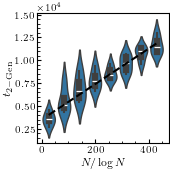

In [ ]:
fig, ax = plt.subplots(figsize=(1.75, 1.75), layout='constrained')
sns.violinplot(ticl, x='theory', y='ticl', native_scale=True, linewidth=1, density_norm='width')
# linear regression of medians
# scientific notation on y axis
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
# 
medians = ticl.groupby('theory', as_index=False)['ticl'].median()
sns.regplot(medians, x='theory', y='ticl', scatter=False, ax=plt.gca(), ci=None, line_kws={'color': 'black', 'linestyle': '--'})
ax.set_xlabel(r'$N/\log N$')
ax.set_ylabel(r'$t_\mathrm{2-Gen}$')

plt.savefig(plot_dir / 'gen_scaling.svg', dpi=300, bbox_inches='tight')